## 1. Setup and Import

In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import missingno as msno

## 2. Data Loading & Initial Inspection

We load the raw dataset into `raw_df` and immediately create `final_df` as the working copy. From this point on, `raw_df` is never modified — it always reflects the original CSV as provided.

In [106]:
raw_df = pd.read_csv("ai_productivity_dataset_final.csv")
final_df = raw_df.copy()

raw_df.info()
raw_df.shape

<class 'pandas.DataFrame'>
RangeIndex: 3248 entries, 0 to 3247
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   task_id                3248 non-null   str    
 1   client                 3248 non-null   str    
 2   project_id             3248 non-null   str    
 3   client_tier            3248 non-null   str    
 4   team                   3248 non-null   str    
 5   task_type              3248 non-null   str    
 6   seniority              3248 non-null   str    
 7   task_complexity_score  3248 non-null   int64  
 8   brief_quality_score    3179 non-null   float64
 9   deadline_pressure      3248 non-null   str    
 10  scope_change_flag      3248 non-null   int64  
 11  pricing_model          3248 non-null   str    
 12  created_at             3248 non-null   str    
 13  delivered_at           3210 non-null   str    
 14  sla_days               3212 non-null   float64
 15  sla_breach     

(3248, 34)

In [107]:
raw_df.describe()

,task_complexity_score,brief_quality_score,scope_change_flag,sla_days,sla_breach,hours_spent,billable_hours,ai_usage_pct,revisions,errors,rework_hours,outcome_score,revenue,cost,profit
count,3248.000000,3179.000000,3248.000000,3212.000000,3248.000000,3248.00000,3166.000000,3104.000000,3248.000000,3248.000000,3176.000000,3115.000000,3248.000000,3248.000000,3248.000000
mean,2.868842,3.183391,0.139163,5.012765,0.398091,13.05551,8.431563,0.361717,3.007697,1.014163,2.437543,68.856918,1120.571260,771.308146,349.263114
std,1.196459,1.211712,0.346169,2.520330,0.489580,11.55750,4.783216,0.199391,1.804829,1.042868,2.911421,12.642211,841.649433,584.269354,888.072715
min,1.000000,1.000000,0.000000,2.000000,0.000000,0.02000,-1.900000,0.000000,0.000000,0.000000,0.000000,9.000000,45.000000,77.850000,-8510.549511
25%,2.000000,2.000000,0.000000,3.000000,0.000000,7.91000,5.080000,0.200000,2.000000,0.000000,1.110000,60.870000,646.312500,440.805000,-2.610000
50%,3.000000,3.000000,0.000000,5.000000,0.000000,11.11500,7.535000,0.340000,3.000000,1.000000,1.810000,69.400000,966.430000,649.065000,254.645000
75%,4.000000,4.000000,0.000000,7.000000,1.000000,15.34500,10.687500,0.500000,4.000000,2.000000,2.950000,77.610000,1364.700000,941.145000,590.400000
max,5.000000,5.000000,1.000000,10.000000,1.000000,263.60018,47.020000,0.930000,11.000000,7.000000,57.517012,100.000000,14927.204324,9409.639511,14006.644324


### 2.1 Duplicate & Identifier Check

We verify whether any rows are fully duplicated and whether `task_id` contains repeated values. Repeated `task_id` entries are inspected to determine if they belong to the same client (likely data versioning) or to different clients (data integrity issue).

In [108]:
# checking if there are duplicated rows
print(final_df.duplicated().sum())

# lista di quali task_id si ripetono due volte
task_id_counts = final_df["task_id"].value_counts()
task_id_repeated = task_id_counts[task_id_counts == 2].index.tolist()
task_id_repeated

0


['T00010',
 'T00139',
 'T00170',
 'T00205',
 'T00219',
 'T00285',
 'T00343',
 'T00413',
 'T00460',
 'T00608',
 'T00617',
 'T00675',
 'T00721',
 'T00726',
 'T00748',
 'T00759',
 'T00875',
 'T00881',
 'T00885',
 'T01075',
 'T01080',
 'T01148',
 'T01151',
 'T01162',
 'T01236',
 'T01344',
 'T01359',
 'T01400',
 'T01476',
 'T01516',
 'T01740',
 'T01849',
 'T01852',
 'T01881',
 'T01915',
 'T01988',
 'T02060',
 'T02075',
 'T02118',
 'T02191',
 'T02295',
 'T02307',
 'T02344',
 'T02652',
 'T02689',
 'T02958',
 'T03121',
 'T03155']

In [109]:
#Verifica che ogni task_id di task_id_repeated appartenga allo stesso client 
for task_id in task_id_repeated:
    client_ids = final_df[final_df["task_id"] == task_id]["client"].unique()
    if len(client_ids) > 1:
        print(f"Task ID {task_id} belongs to multiple clients: {client_ids}")

Task ID T00010 belongs to multiple clients: <StringArray>
['Client_F', 'Client_J']
Length: 2, dtype: str
Task ID T00726 belongs to multiple clients: <StringArray>
['Client_[', 'Client_F']
Length: 2, dtype: str
Task ID T00875 belongs to multiple clients: <StringArray>
['Client_C', 'Client_W']
Length: 2, dtype: str
Task ID T01080 belongs to multiple clients: <StringArray>
['Client_D', 'Client_M']
Length: 2, dtype: str
Task ID T01740 belongs to multiple clients: <StringArray>
['Client_A', 'Client_S']
Length: 2, dtype: str
Task ID T02295 belongs to multiple clients: <StringArray>
['Client_W', 'Client_K']
Length: 2, dtype: str


## 3. Categorical Variable Cleaning

Several categorical columns contain label inconsistencies (typos, mixed case, alternate naming conventions). We standardise each one before any analysis.

### 3.1 `team`

Lowercasing, stripping whitespace, and correcting typos (`contennt` → `content`, `desgn` → `design`).

In [110]:
final_df["team"].value_counts()

# team is used to classify the different teams working on the projects
# we can obsserve that there are some repetitions and errors so I need to fix them

final_df["team"] = final_df["team"].str.lower()
final_df["team"] = final_df["team"].str.strip()

# I need to convert the value "contennt" to "content" in the team name column
final_df["team"] = final_df["team"].replace("contennt", "content")
final_df["team"] = final_df["team"].replace("desgn", "design")

# paid_media has significantly fewer observations than media — merging into media 
final_df["team"] = final_df["team"].replace("paid media", "media") 
final_df["team"].value_counts()

team
content    835
media      821
design     798
seo        794
Name: count, dtype: int64

### 3.2 `task_type`

Lowercasing, stripping, and consolidating multiple label variants into canonical categories.

In [111]:
# we need to clean the task_type column as well
final_df["task_type"] = final_df["task_type"].str.lower()
final_df["task_type"] = final_df["task_type"].str.strip()

final_df["task_type"] = final_df["task_type"].replace("relese", "release")
final_df["task_type"] = final_df["task_type"].replace("release_task", "release")
final_df["task_type"] = final_df["task_type"].replace("dev_task", "dev")
final_df["task_type"] = final_df["task_type"].replace("ad_task", "ad")
final_df["task_type"] = final_df["task_type"].replace("article_task", "article")
final_df["task_type"] = final_df["task_type"].replace("artcle", "article")
final_df["task_type"] = final_df["task_type"].replace("repport", "report")
final_df["task_type"] = final_df["task_type"].replace("report_task", "report")
final_df["task_type"] = final_df["task_type"].replace("design_task", "design")
final_df["task_type"] = final_df["task_type"].replace("ticket_task", "ticket")
final_df["task_type"] = final_df["task_type"].replace("dev", "development")

# merge low-frequency subcategories into their parent categories  
final_df["task_type"] = final_df["task_type"].replace("blog_article", "article")  
final_df["task_type"] = final_df["task_type"].replace("paid_ad", "ad")  
final_df["task_type"] = final_df["task_type"].replace("support_ticket", "ticket")  
final_df["task_type"] = final_df["task_type"].replace("creative", "design")  
final_df["task_type"].value_counts()

task_type
design         478
ad             474
ticket         473
article        468
report         466
development    446
release        443
Name: count, dtype: int64

### 3.3 Remaining Categorical Variables — Value Inspection

No cleaning was required for the remaining categorical columns. We inspect them to confirm label consistency and understand their distributions.

In [112]:
final_df["client_tier"].value_counts()
# client tier is used to classify the "importance" in terms of value/revenues of the different clients

client_tier
mid     1514
low      877
high     857
Name: count, dtype: int64

In [113]:
final_df["seniority"].value_counts()

seniority
mid       1296
junior    1190
senior     762
Name: count, dtype: int64

In [114]:
final_df["deadline_pressure"].value_counts()

deadline_pressure
medium    1482
low        914
high       852
Name: count, dtype: int64

In [115]:
final_df["pricing_model"].value_counts()

pricing_model
hourly         1561
fixed          1227
value_based     460
Name: count, dtype: int64

In [116]:
final_df["task_status"].value_counts()

task_status
in_progress    1129
review          866
delivered       769
draft           183
archived        151
blocked         150
Name: count, dtype: int64

In [117]:
final_df["workflow_stage"].value_counts()

workflow_stage
qa               687
client_review    664
finalized        643
briefing         640
execution        614
Name: count, dtype: int64

In [118]:
final_df["content_version"].value_counts()

content_version
v1       926
v2       775
v3       667
final    560
v4       320
Name: count, dtype: int64

In [119]:
final_df["legacy_ai_flag"].value_counts()

legacy_ai_flag
false      1458
true       1451
unknown     339
Name: count, dtype: int64

In [120]:
final_df["scope_change_flag"].value_counts()  
#it may mean that the scope of the task has changed during its execution    

scope_change_flag
0    2796
1     452
Name: count, dtype: int64

In [121]:
# The "jira_ticket" variable represents a unique identifier linking each task to its corresponding record in the Jira system.
# The 'jira_ticket' column contains approximately 10% missing values, representing tasks not tracked in the Jira system.
# As this variable is an identifier and does not provide predictive information, it was excluded from further analysis.
final_df["jira_ticket"].value_counts()

jira_ticket
JIRA-53111    2
JIRA-67759    2
JIRA-38743    2
JIRA-62438    2
JIRA-36863    2
             ..
JIRA-42947    1
JIRA-90491    1
JIRA-19154    1
JIRA-32851    1
JIRA-39958    1
Name: count, Length: 2868, dtype: int64

## 4. Date Variables Conversion

The columns `created_at`, `delivered_at`, and `updated_at` are stored as strings and must be converted to datetime objects to enable time-based feature engineering.

In [122]:
# I need to convert "created_at", "delivered_at" and "updated_at" to datetime since they are str
final_df["created_at"] = pd.to_datetime(final_df["created_at"], errors="coerce")
final_df["delivered_at"] = pd.to_datetime(final_df["delivered_at"], errors="coerce")
final_df["updated_at"] = pd.to_datetime(final_df["updated_at"], errors="coerce")
final_df[["created_at", "delivered_at", "updated_at"]].head()

,created_at,delivered_at,updated_at
0,2025-11-20,2025-11-25,2025-11-28
1,2026-01-24,2026-01-26,2026-01-26
2,2025-09-16,2025-09-23,2025-09-17
3,2025-11-06,2025-11-09,2025-11-12
4,2026-05-02,2026-05-06,2026-05-09


## 5. Missing Value Treatment

We first visualise the overall missing value pattern, then treat each affected column individually with a justified imputation strategy.

In [123]:
# checking the missing values for each column
missing_values = final_df.isnull().sum()
missing_percentage = (missing_values / final_df.shape[0]) * 100

missing_summary = pd.DataFrame({"count": missing_values, "pct": missing_percentage})
missing_summary[missing_summary["count"] > 0]
# columns that contain missing: brief_quality_score, delivered_at, sla_days, billable_hours, ai_usage_pct, rework_hours, outcome_score, jira_ticket

,count,pct
brief_quality_score,69,2.124384
delivered_at,38,1.169951
sla_days,36,1.108374
billable_hours,82,2.524631
ai_usage_pct,144,4.433498
rework_hours,72,2.216749
outcome_score,133,4.094828
jira_ticket,339,10.437192


<Axes: >

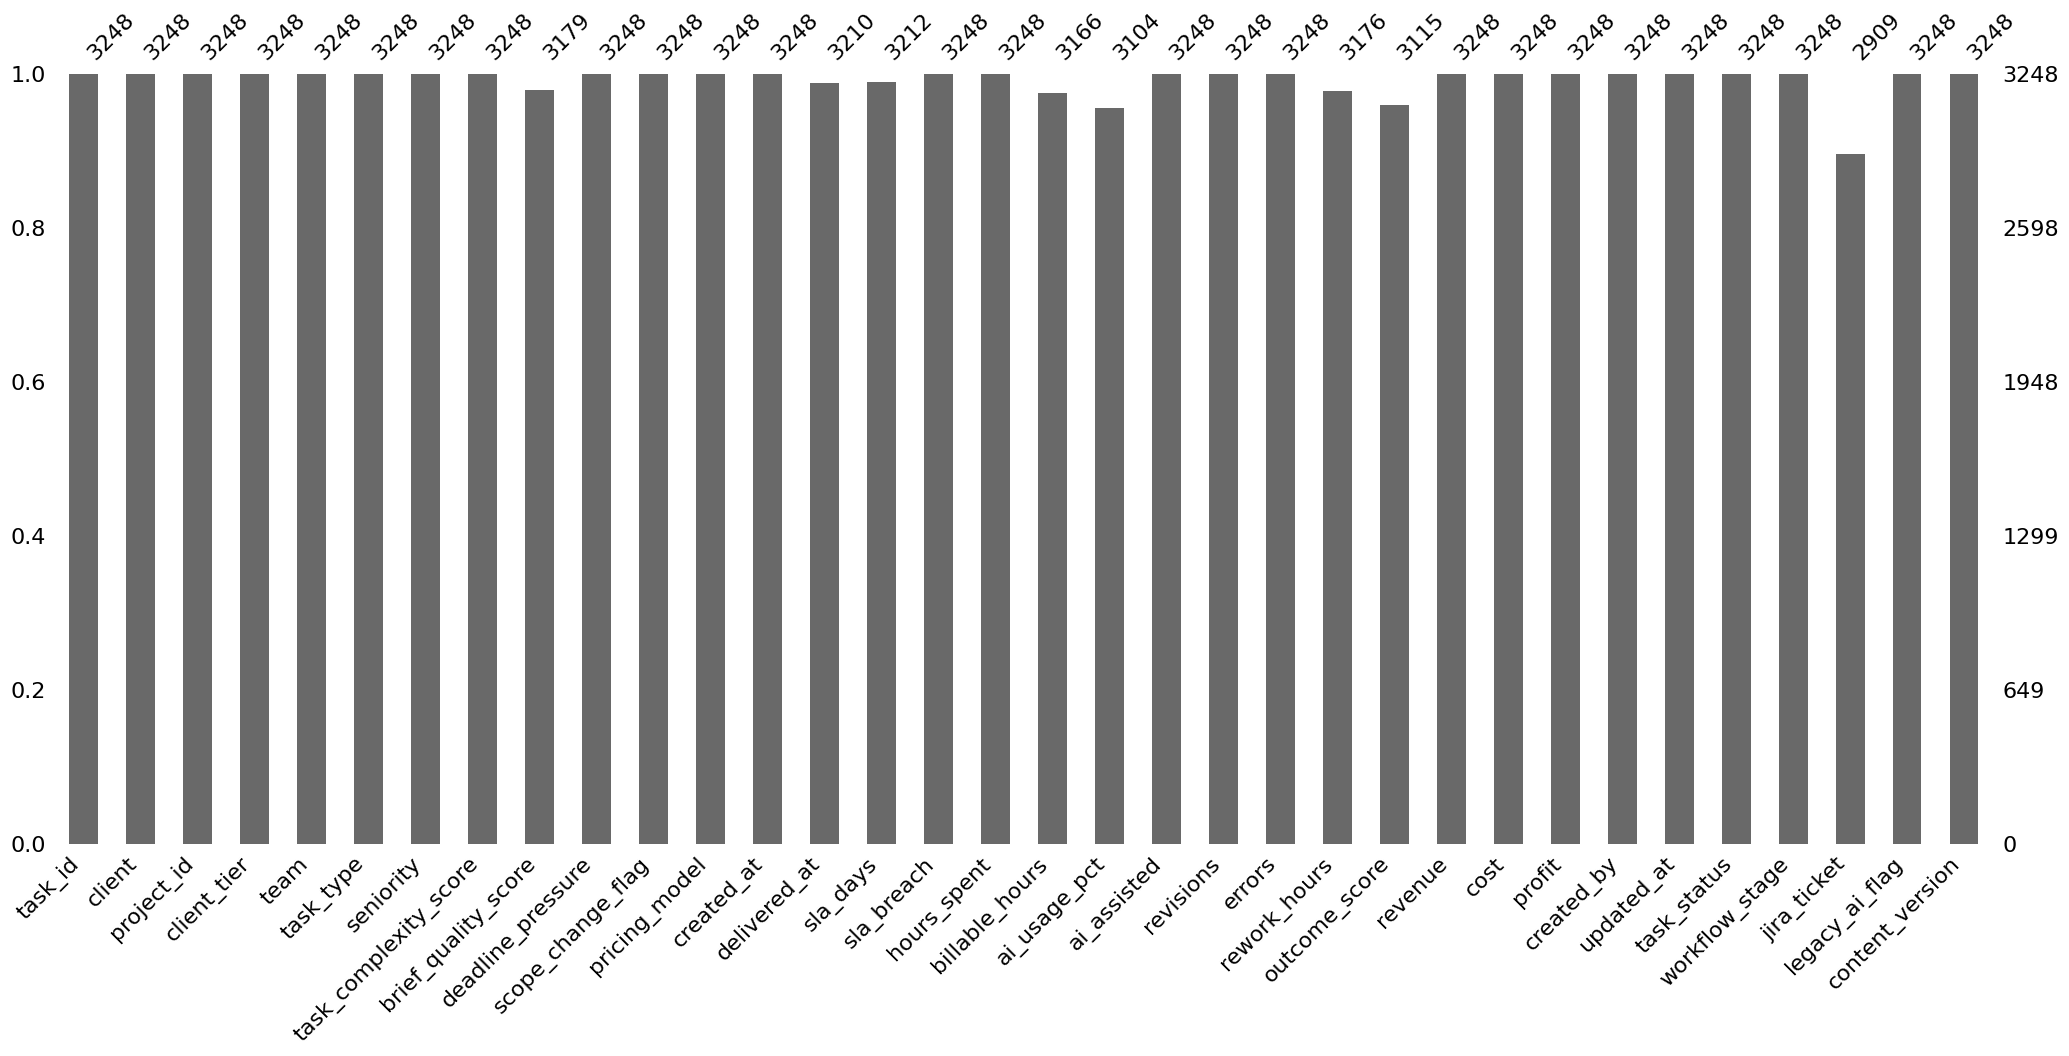

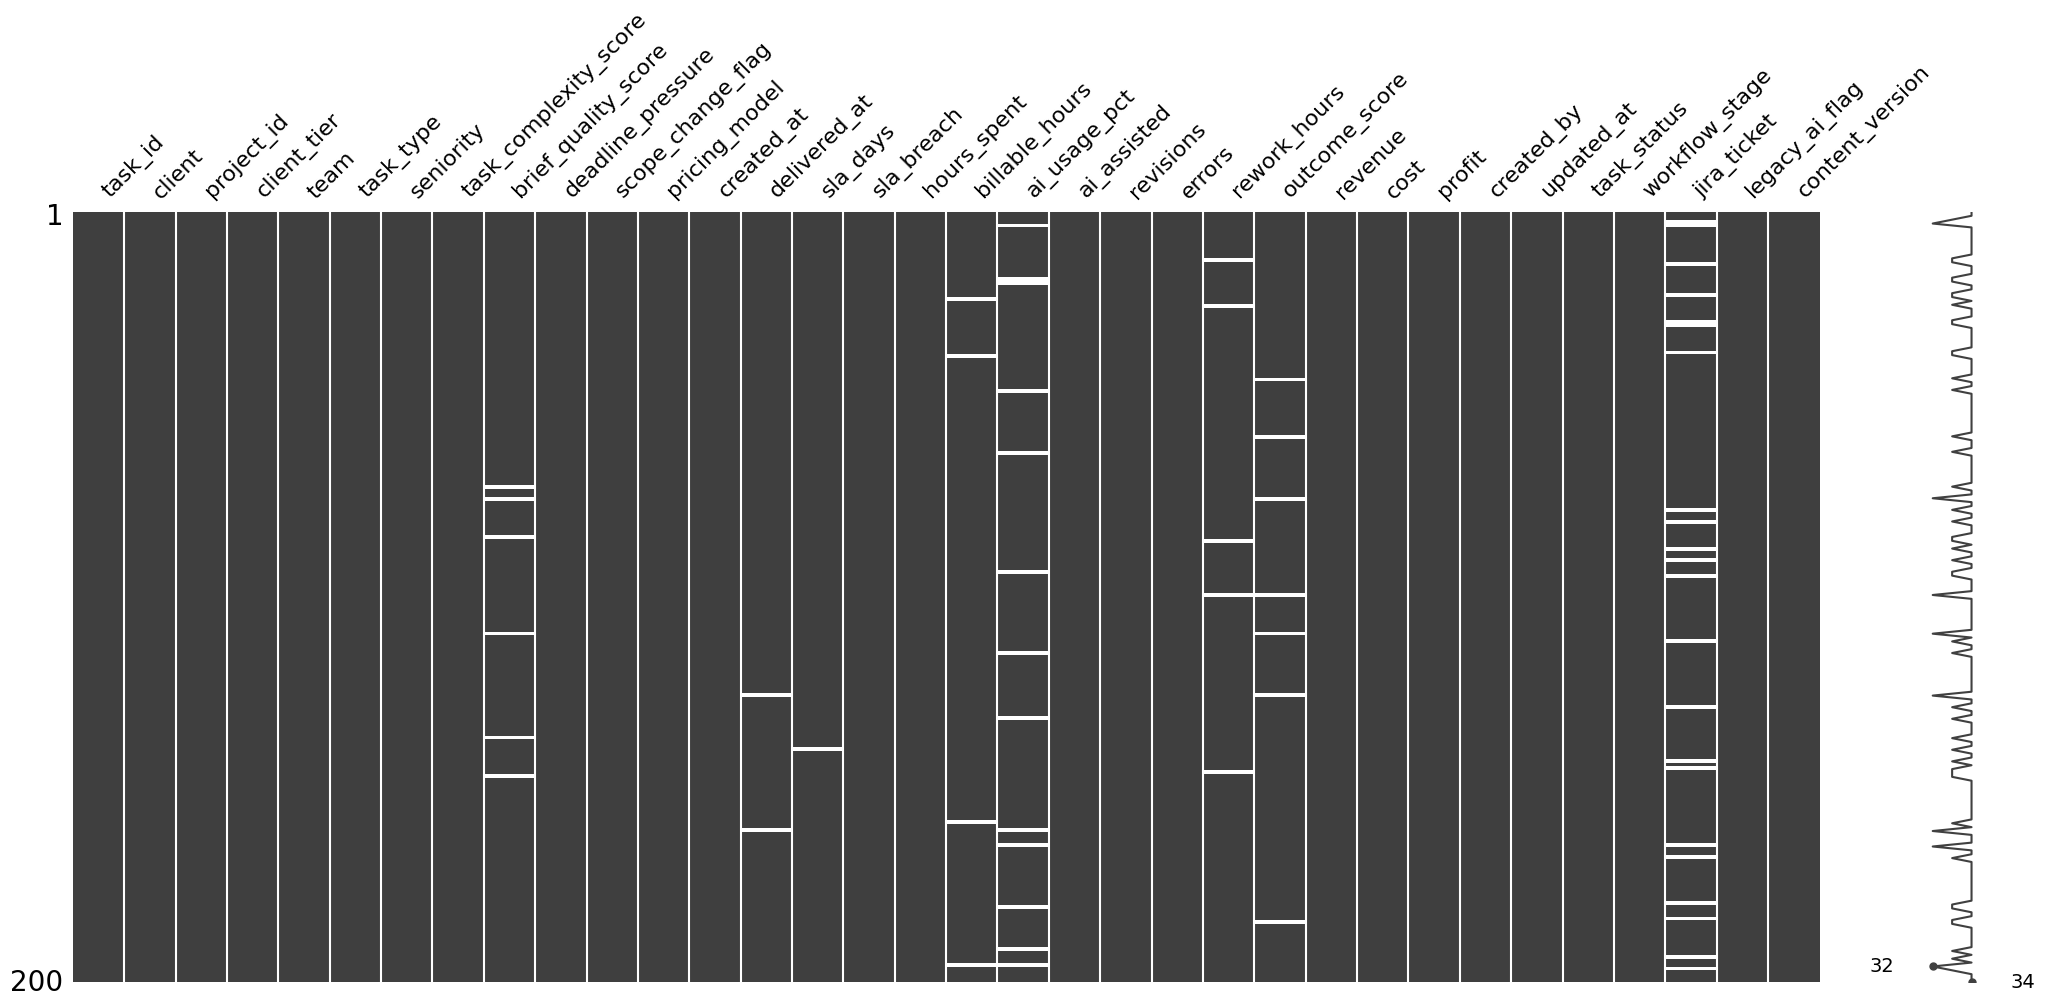

In [124]:
# visualization of columns that contain missing values
msno.bar(final_df)
msno.matrix(final_df.sample(200))

### 5.1 `brief_quality_score` — Median imputation (MCAR)

~2.1% of values are missing. A comparison of key metrics between rows with and without missing `brief_quality_score` shows near-identical means, indicating Missing Completely At Random (MCAR). We impute with the overall median.

In [125]:
final_df["missing_flag"] = final_df["brief_quality_score"].isna().astype(int)
final_df.groupby("missing_flag").mean(numeric_only=True)

# An analysis comparing missing vs non missing observations showed that missing values are almost completely at random (MCAR)
# as they are associated with very little differences in variables such as task duration, SLA breach and scope

,task_complexity_score,brief_quality_score,scope_change_flag,sla_days,sla_breach,hours_spent,billable_hours,ai_usage_pct,ai_assisted,revisions,errors,rework_hours,outcome_score,revenue,cost,profit
missing_flag,,,,,,,,,,,,,,,,
0,2.872287,3.183391,0.137779,5.007952,0.397295,13.034793,8.456453,0.362091,0.789242,3.012583,1.019188,2.433118,68.831279,1120.871426,773.545388,347.326038
1,2.710145,NaN,0.202899,5.235294,0.434783,14.010008,7.297647,0.344776,0.753623,2.782609,0.782609,2.639808,70.041364,1106.741895,668.232899,438.508997


In [126]:
final_df["brief_quality_score"] = final_df["brief_quality_score"].fillna(final_df["brief_quality_score"].median())

### 5.2 `delivered_at` — True missing (no imputation)

We verify whether tasks with a missing `delivered_at` are genuinely not-yet-delivered or true data errors. Since tasks with `task_status != 'delivered'` can still have a non-null `delivered_at`, the missingness is confirmed to be true missing data. No imputation is applied.

In [127]:
missing_values = final_df[final_df["delivered_at"].isnull()]["task_status"].value_counts()
missing_values

task_status
delivered      13
in_progress    12
review          7
archived        4
blocked         1
draft           1
Name: count, dtype: int64

In [128]:
final_df[final_df["task_status"] != "delivered"]["delivered_at"].notna().sum()
# As we can see from the analysis above, there are observations with "delivered_at" not null but with "task_status" different from "delivered",
# so the missingness are true missing

np.int64(2454)

### 5.3 `sla_days` — Median imputation (MCAR)

Missing rows show no systematic pattern across other variables. Missingness is treated as MCAR and imputed with the overall median.

In [129]:
# I can inpute sla_days missings with the median since the missings are completely at random
final_df["sla_days"] = final_df["sla_days"].fillna(final_df["sla_days"].median())

### 5.4 `billable_hours` — Group-based median imputation

~2.5% of values are missing. Inspection confirms these are true missing values, not zero-billable tasks. A group-based median imputation by `pricing_model` and `task_type` is applied to preserve business structure, followed by a global median fallback for any remaining cases.

In [130]:
final_df[final_df["billable_hours"].isna()][["task_status", "pricing_model", "hours_spent", "revenue", "cost", "profit"]].head(50)
final_df["billable_hours"] = final_df.groupby(["pricing_model", "task_type"])["billable_hours"].transform(lambda x: x.fillna(x.median()))

final_df["billable_hours"] = final_df["billable_hours"].fillna(final_df["billable_hours"].median())

# Missing values in "billable_hours" were analyzed and found to be true missing data rather than non-billable tasks and as highlighted before only 2.52% of the column's values.
# A group-based median imputation (by pricing_model and task_type) was applied to preserve business structure, followed by a global median fallback for remaining cases (only one obs).

### 5.5 `ai_usage_pct` — Median imputation (MCAR)

~4.5% of values are missing. The missing rate is similar across `legacy_ai_flag` groups, ruling out a systematic relationship. Analysis of legacy tasks shows a median AI usage of ~34%, confirming that missing values do not represent absence of AI. We impute with the overall median.

In [131]:
final_df[final_df["legacy_ai_flag"] == "true"]["ai_usage_pct"].describe()
# An analysis of "ai_usage_pct" within legacy tasks showed a median usage of 0.34%, indicating that AI was actively used even in legacy data.
# Therefore, missing values do not represent absence of AI usage but rather missing information.

count    1381.000000
mean        0.365243
std         0.202176
min         0.010000
25%         0.200000
50%         0.340000
75%         0.510000
max         0.930000
Name: ai_usage_pct, dtype: float64

In [132]:
final_df.groupby("legacy_ai_flag")["ai_usage_pct"].apply(lambda x: x.isna().mean())

# An analysis of missing values in 'ai_usage_pct' (4.5%) showed no significant differences across 'legacy_ai_flag' categories,
# indicating that missingness is not related to legacy system usage. For this reason I can inpute using the median.

final_df["ai_usage_pct"] = final_df["ai_usage_pct"].fillna(final_df["ai_usage_pct"].median())

### 5.6 `rework_hours` — Median imputation (true missing)

~2.2% of values are missing. Since `rework_hours` can be positive even when `errors = 0` and `revisions = 0`, missing values cannot be interpreted as zero. They are treated as true missing and imputed with the median.

In [133]:
final_df[final_df["rework_hours"].isna()][["errors", "revisions","task_status", "outcome_score"]].head(50)

,errors,revisions,task_status,outcome_score
47,1,3,in_progress,77.98
82,0,2,in_progress,68.17
89,2,4,delivered,55.63
138,0,4,review,71.45
158,0,3,delivered,86.61
160,0,4,in_progress,75.92
176,4,1,in_progress,79.97
203,1,0,delivered,43.72
219,0,7,delivered,73.94
221,1,1,delivered,55.59


In [134]:
final_df[final_df["errors"] == 0]["rework_hours"].describe()
final_df[final_df["revisions"] == 0]["rework_hours"].describe()

count    168.000000
mean       1.782202
std        1.338072
min        0.000000
25%        0.935000
50%        1.485000
75%        2.297500
max        8.310000
Name: rework_hours, dtype: float64

In [135]:
final_df["rework_hours"] = final_df["rework_hours"].fillna(final_df["rework_hours"].median())

# since missing "rework_hours" represent only 2,2% of the total data and "rework_hours" are present when no errors/revisions are made, missing values cannot be interpreted as 0.
# For these reasons they were treated as true missing data

### 5.7 `outcome_score` — Median imputation (MCAR)

Missing `outcome_score` does not depend on `task_status` or `workflow_stage`, confirming MCAR. We impute with the overall median.

In [136]:
final_df.groupby("task_status")["outcome_score"].describe()
final_df[final_df["outcome_score"].isna()][["task_status", "workflow_stage", "delivered_at"]].head(50)

# since outcome_score does not depend on task_status or workflow_stage, we can use the overall median
final_df["outcome_score"] = final_df["outcome_score"].fillna(final_df["outcome_score"].median())

### 5.8 Final Missing Value Check

After all imputations, we verify that no treatable missing values remain.

In [137]:
missing_values = final_df.isnull().sum()
missing_values[missing_values > 0]

delivered_at     38
jira_ticket     339
dtype: int64

## 6. Exploratory Data Analysis (EDA)

We explore distributions and relationships through a correlation heatmap, histograms of key numeric variables, countplots for categorical variables, and boxplots comparing categories against the main outcome variables.

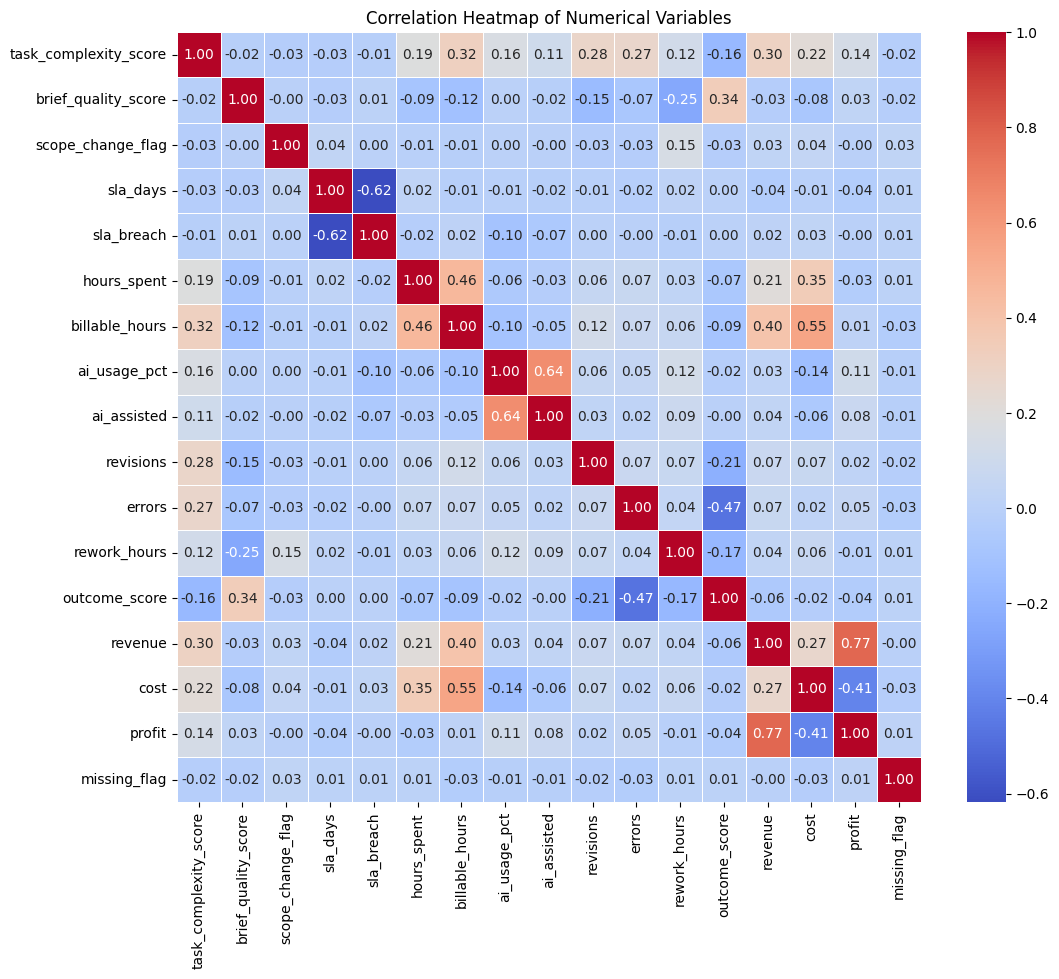

In [138]:
#heatmap of correlation between numerical variables
plt.figure(figsize=(12, 10))
sns.heatmap(final_df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

#the most correlated variables are billable_hours and cost (0.55), ai_usage_pct and ai_assisted (0.64) and revenue and profit (0.77)
#while sla_days and sla_breach are negatively correlated (-0.62) and also error and outcome_score(-0.47)but also cost 

In [139]:
num_cols = final_df.select_dtypes(include=np.number).columns.tolist()
num_cols

['task_complexity_score',
 'brief_quality_score',
 'scope_change_flag',
 'sla_days',
 'sla_breach',
 'hours_spent',
 'billable_hours',
 'ai_usage_pct',
 'revisions',
 'errors',
 'rework_hours',
 'outcome_score',
 'revenue',
 'cost',
 'profit',
 'missing_flag']

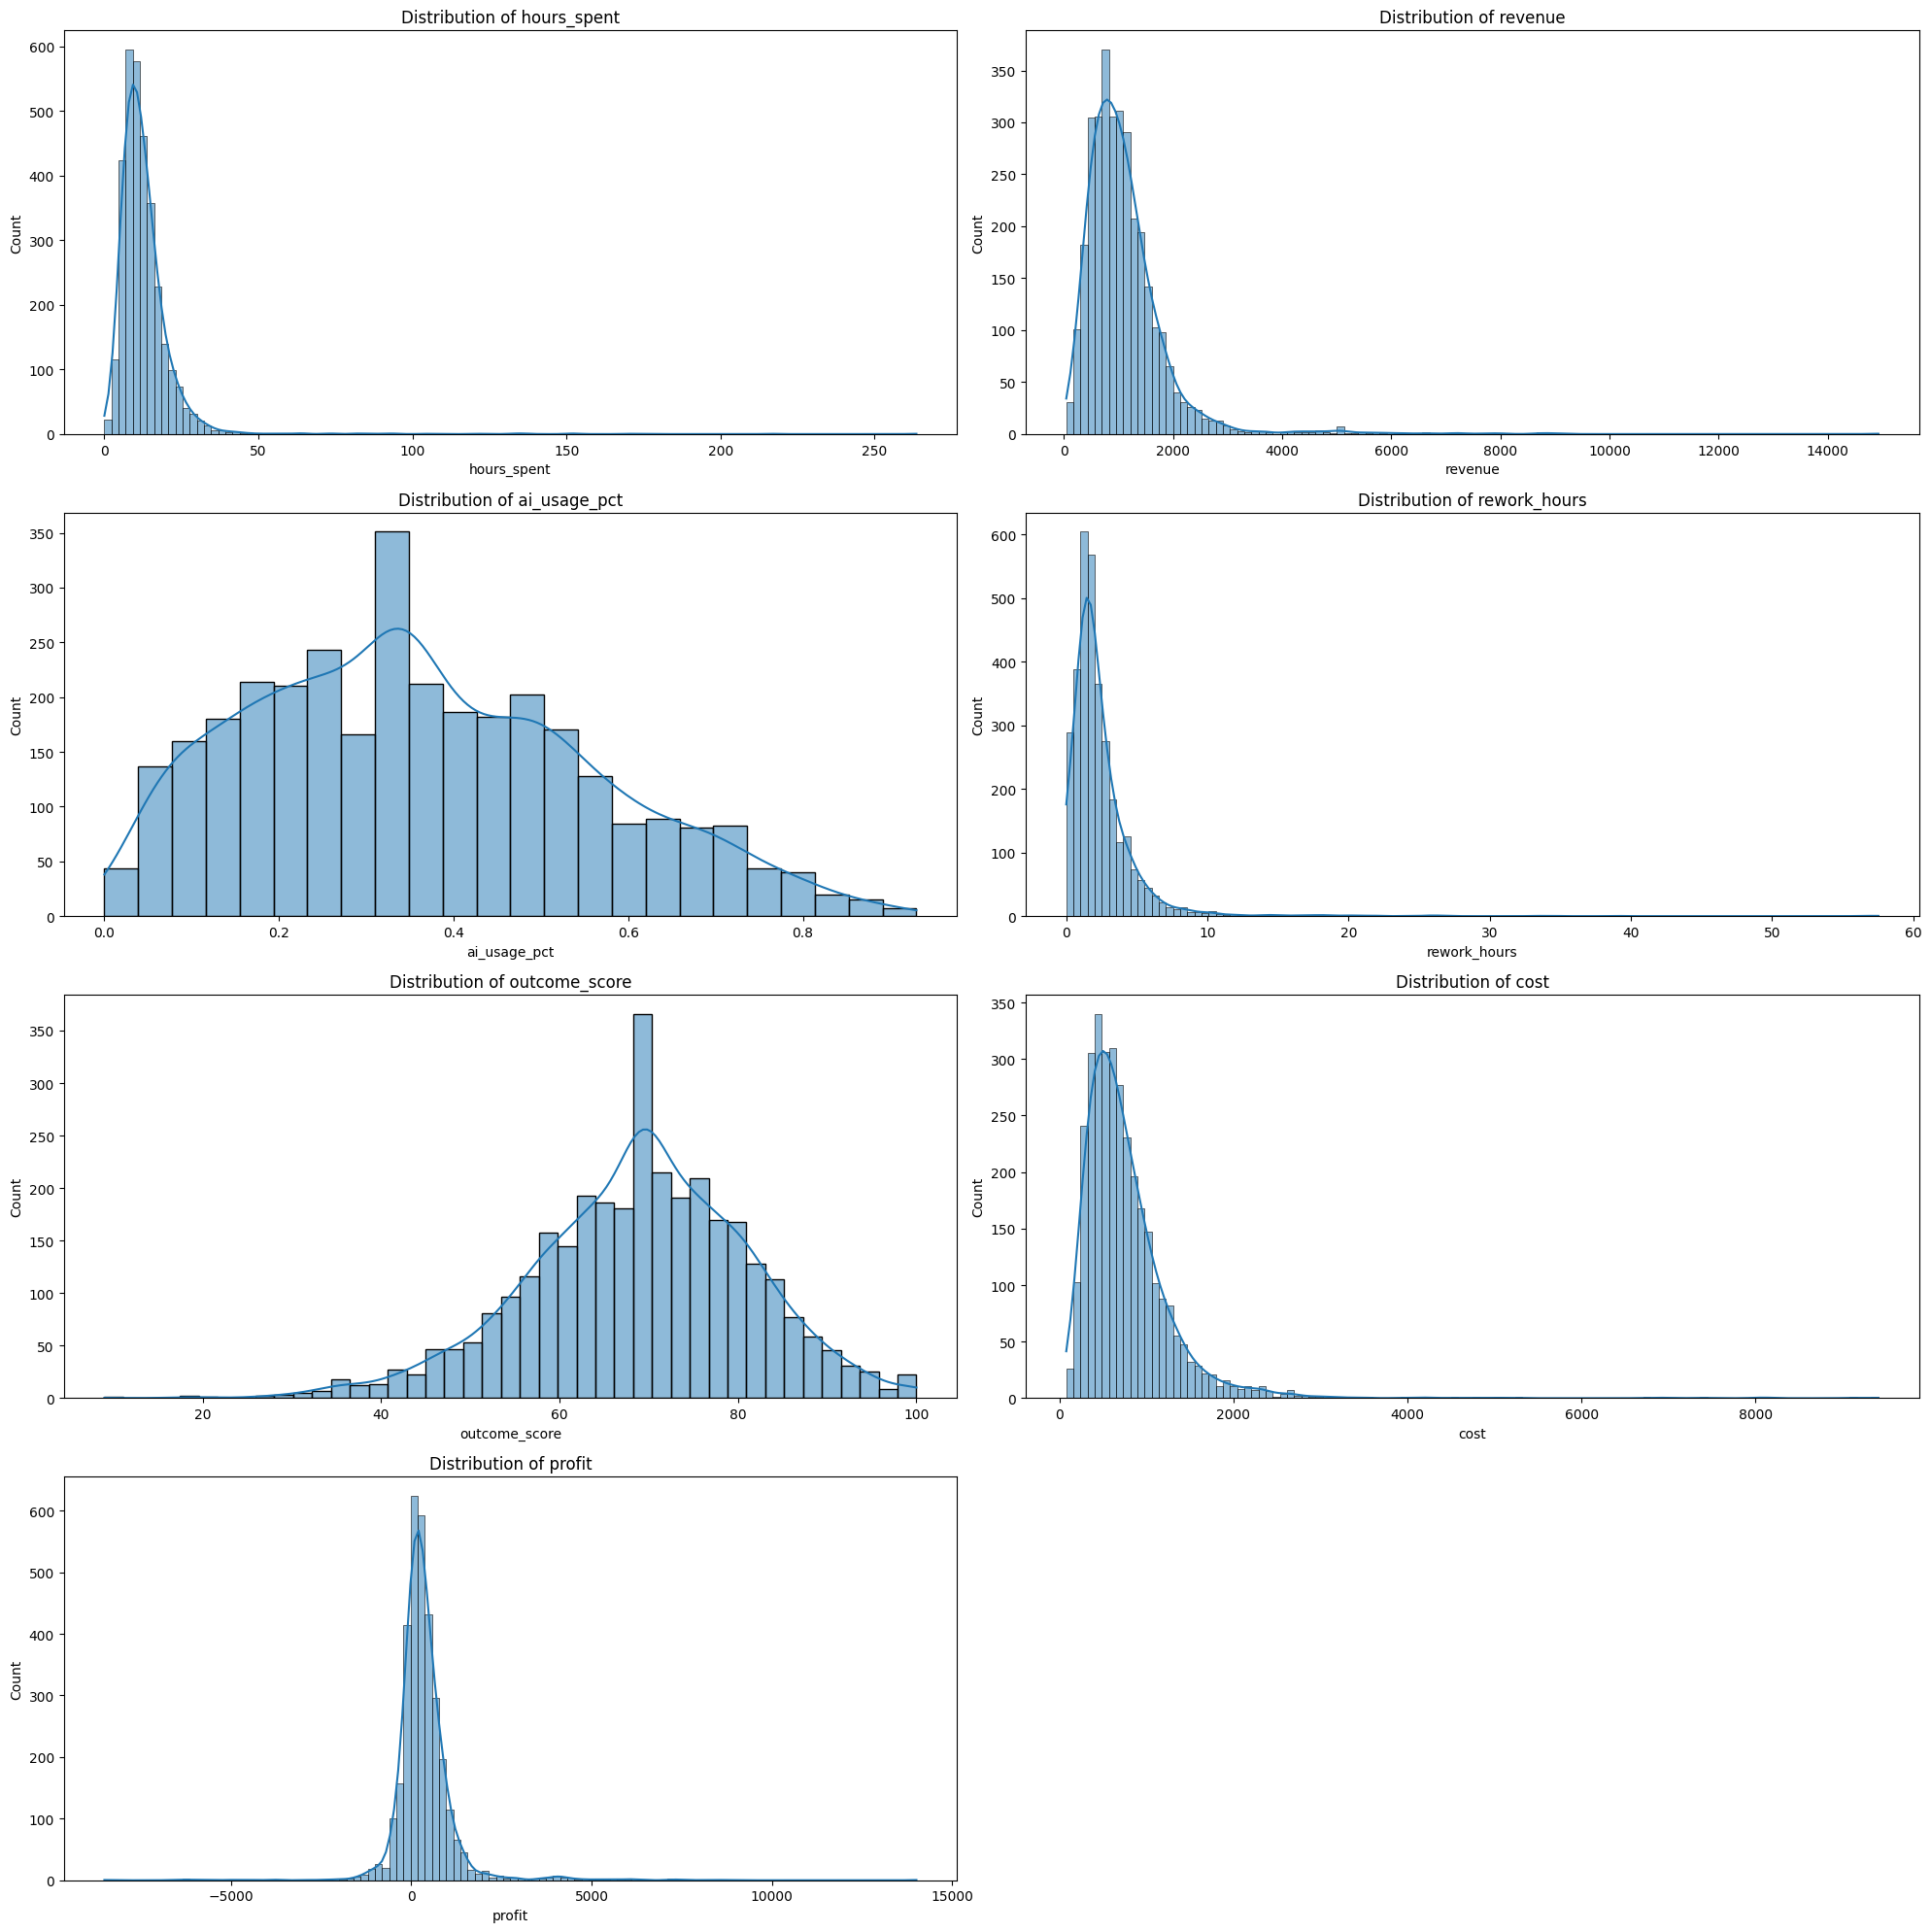

In [140]:
#distribution of hours_spent, revenue, ai_usage_pct, rework_hours, outcome_score, cost and profit
plt.figure(figsize=(20, 20))
cols_to_plot = ["hours_spent", "revenue", "ai_usage_pct", "rework_hours", "outcome_score", "cost", "profit"]
for i, col in enumerate(cols_to_plot):
    plt.subplot(4, 2, i + 1)
    sns.histplot(final_df[col], kde=True)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

Distribution observations:
- The variables `hours_spent`, `billable_hours`, `rework_hours`, `revenue`, and `cost` show strong right-skewness with obvious outliers. A log transformation may be necessary before modeling.
- `scope_change_flag` and `sla_breach` are binary and unbalanced.
- `outcome_score` has an approximately left-normal distribution, suitable as a target variable.
- `profit` has a bimodal distribution with both positive and negative values, suggesting the existence of structurally different task segments.

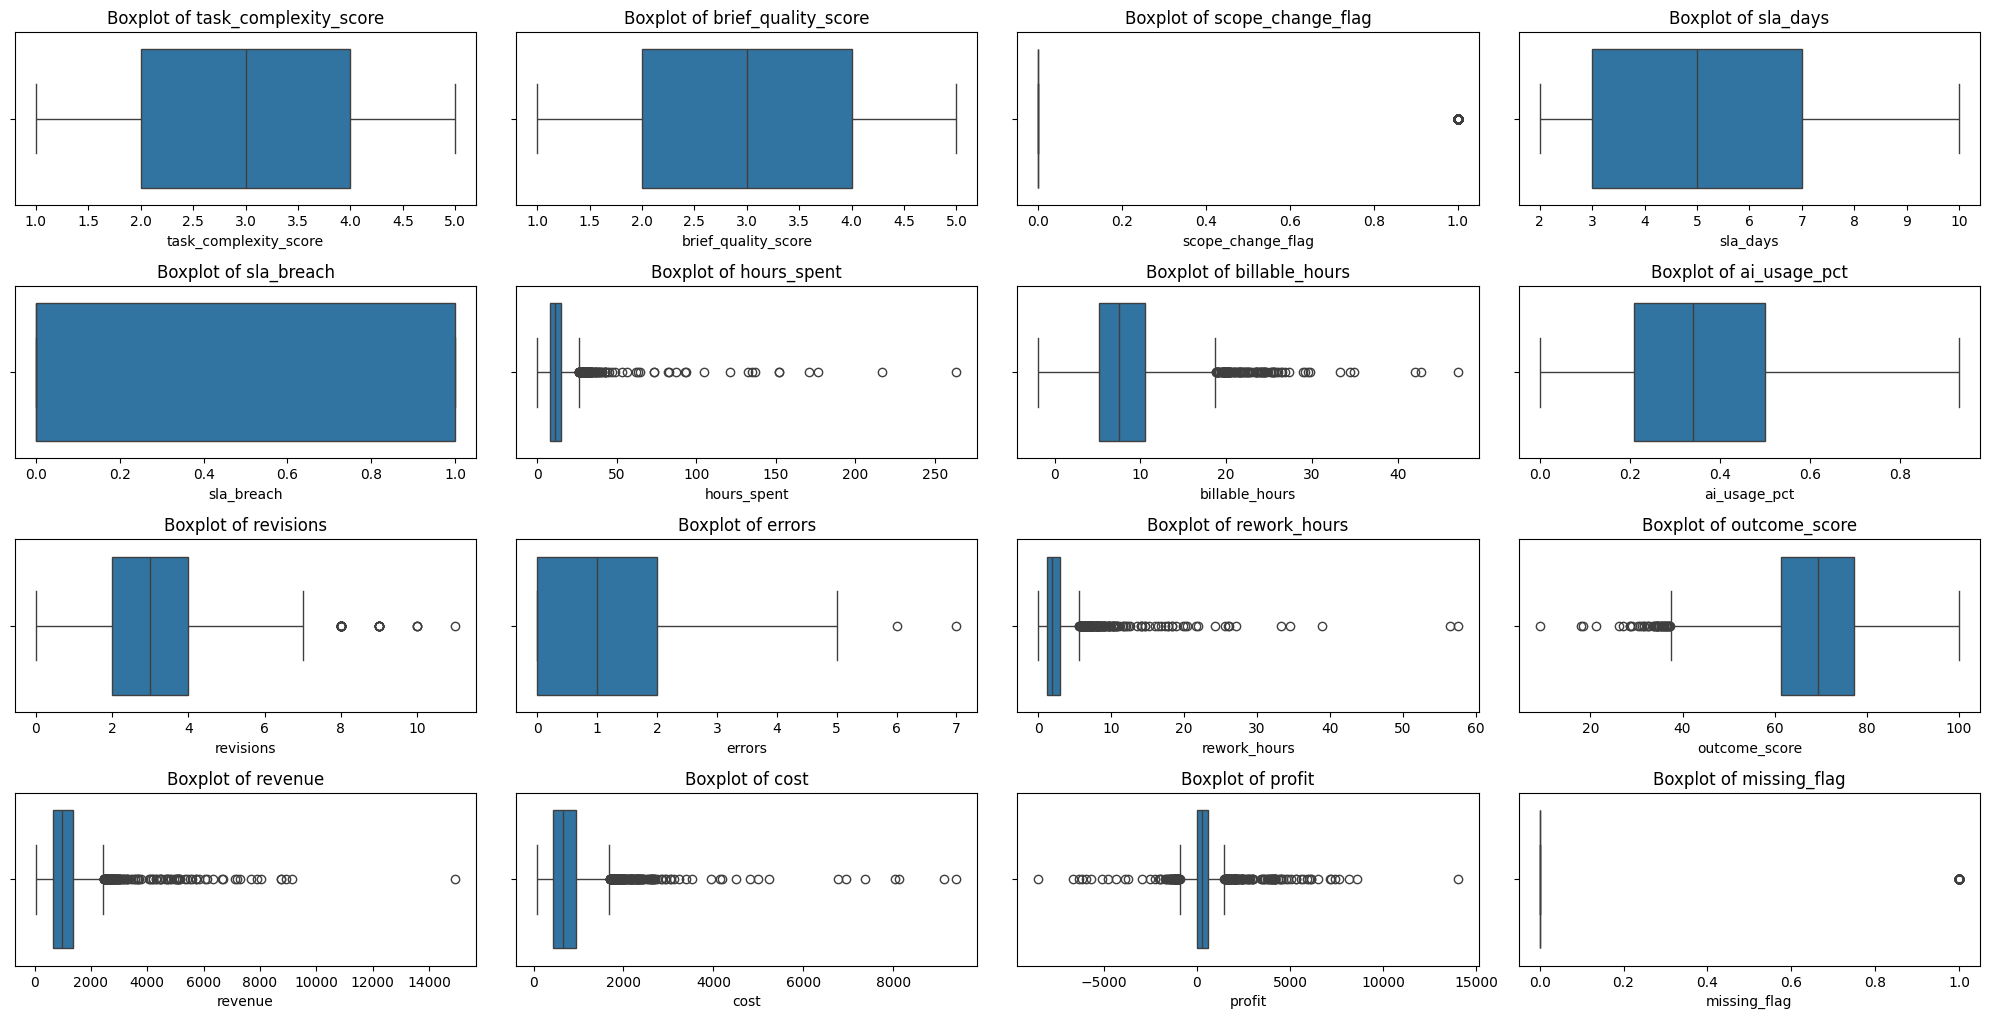

In [141]:
#boxplot for numerical columns 
plt.figure(figsize=(20, 20))
for i, col in enumerate(num_cols):
    plt.subplot(8, 4, i + 1)
    sns.boxplot(x=final_df[col])
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

In [142]:
cat_cols = ["team", "task_type", "seniority", "task_status", 
            "workflow_stage", "client_tier", "pricing_model", 
            "deadline_pressure", "ai_assisted", "legacy_ai_flag",
            "scope_change_flag", "content_version"]

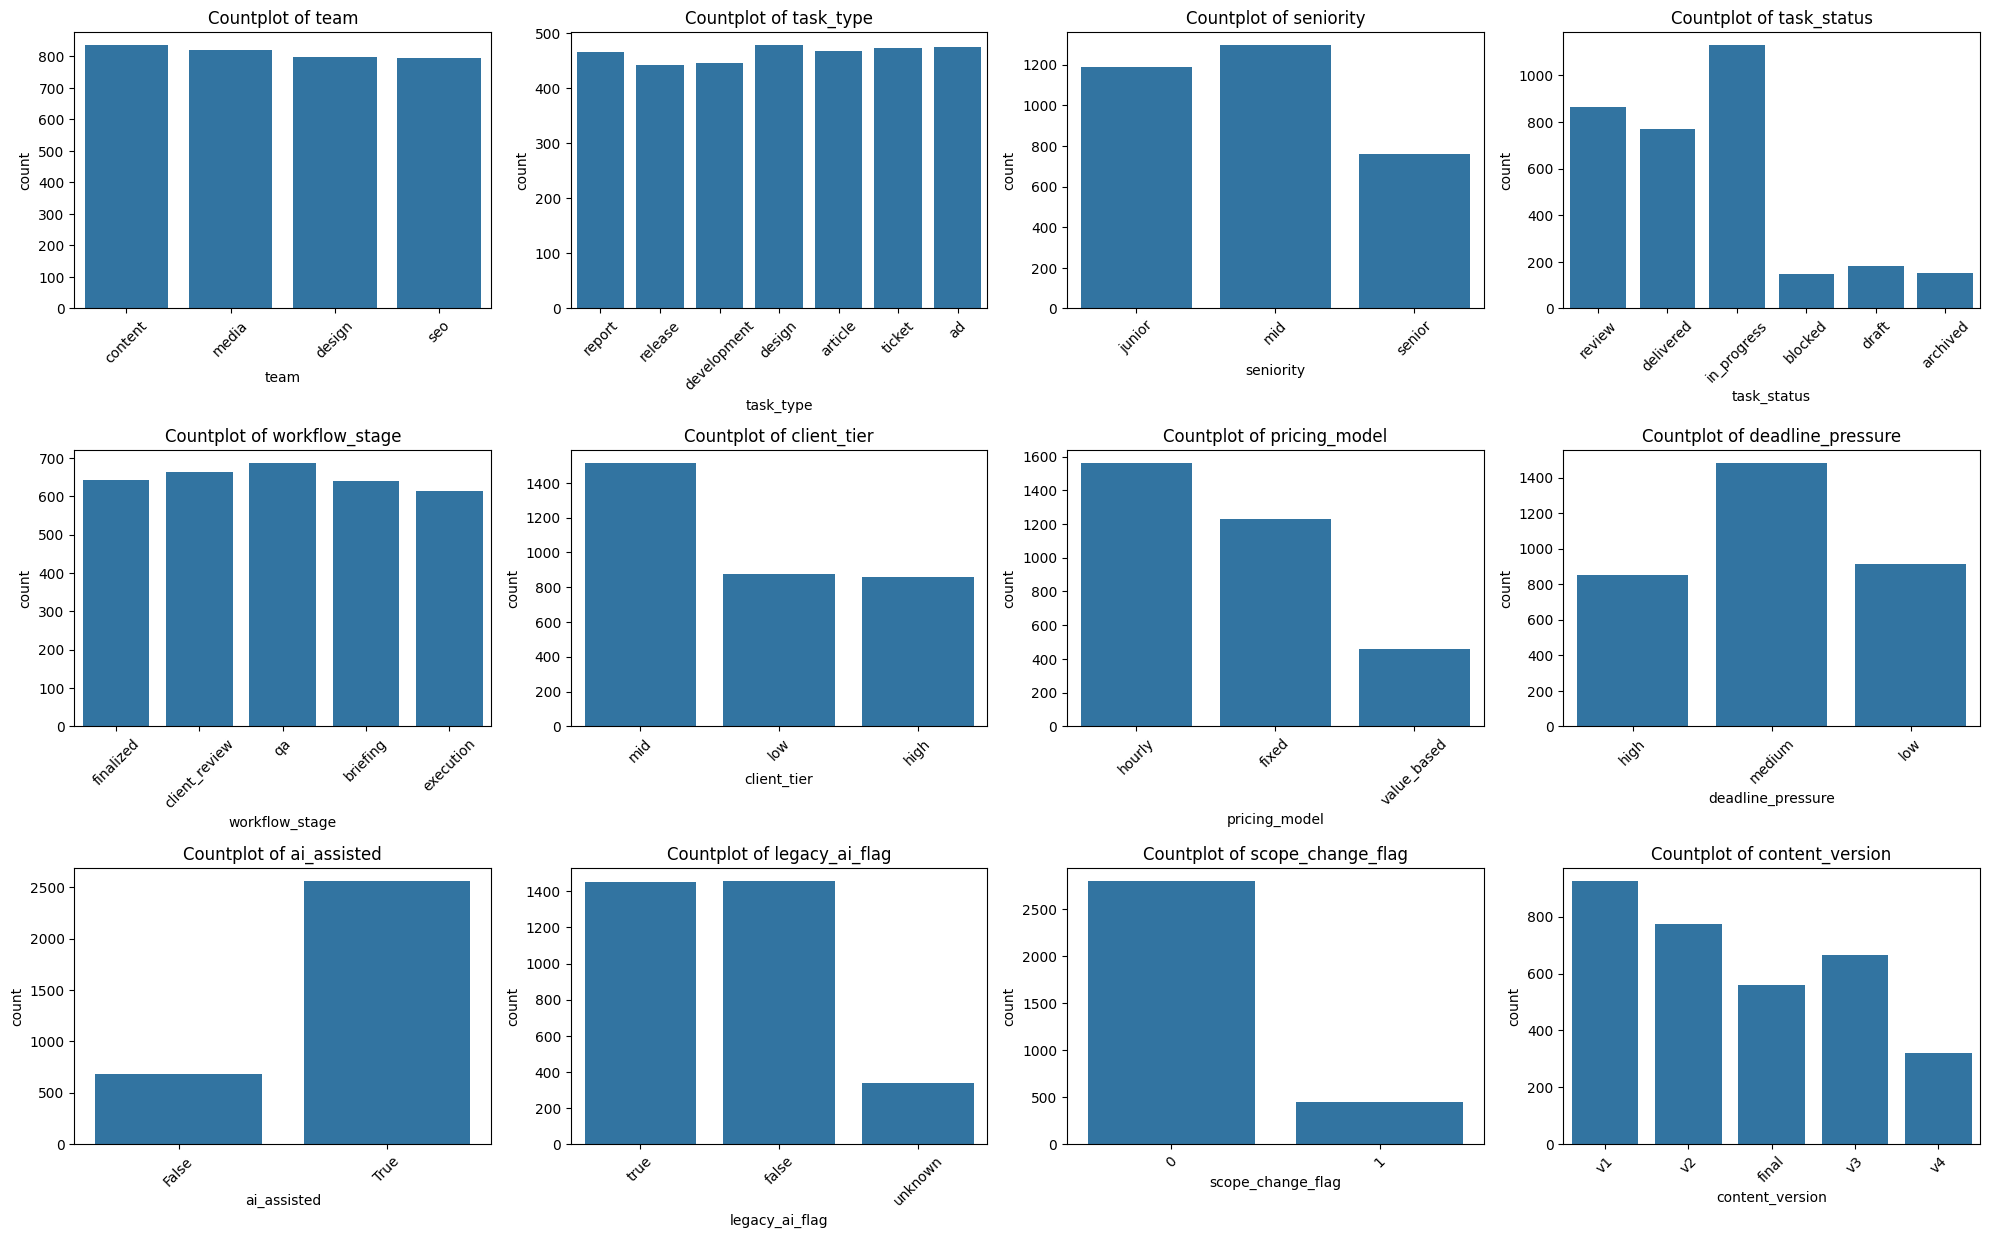

In [143]:
#only an image with all this plots together
plt.figure(figsize=(20, 20))
for i, col in enumerate(cat_cols):
    plt.subplot(5, 4, i + 1)
    sns.countplot(data=final_df, x=col)
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)     
plt.tight_layout()
plt.show()

Categorical distribution notes:
- **TEAM:** `paid_media` has significantly fewer observations than `media` — consider merging.
- **TASK_TYPE:** Several low-frequency categories (`creative`, `blog_article`, `paid_ad`) — consider consolidating with larger groups.
- **SENIORITY:** Unbalanced distribution with significantly more junior and mid-level than senior staff. Normal in an agency context, but must be accounted for to avoid over- or underestimating the seniority effect.

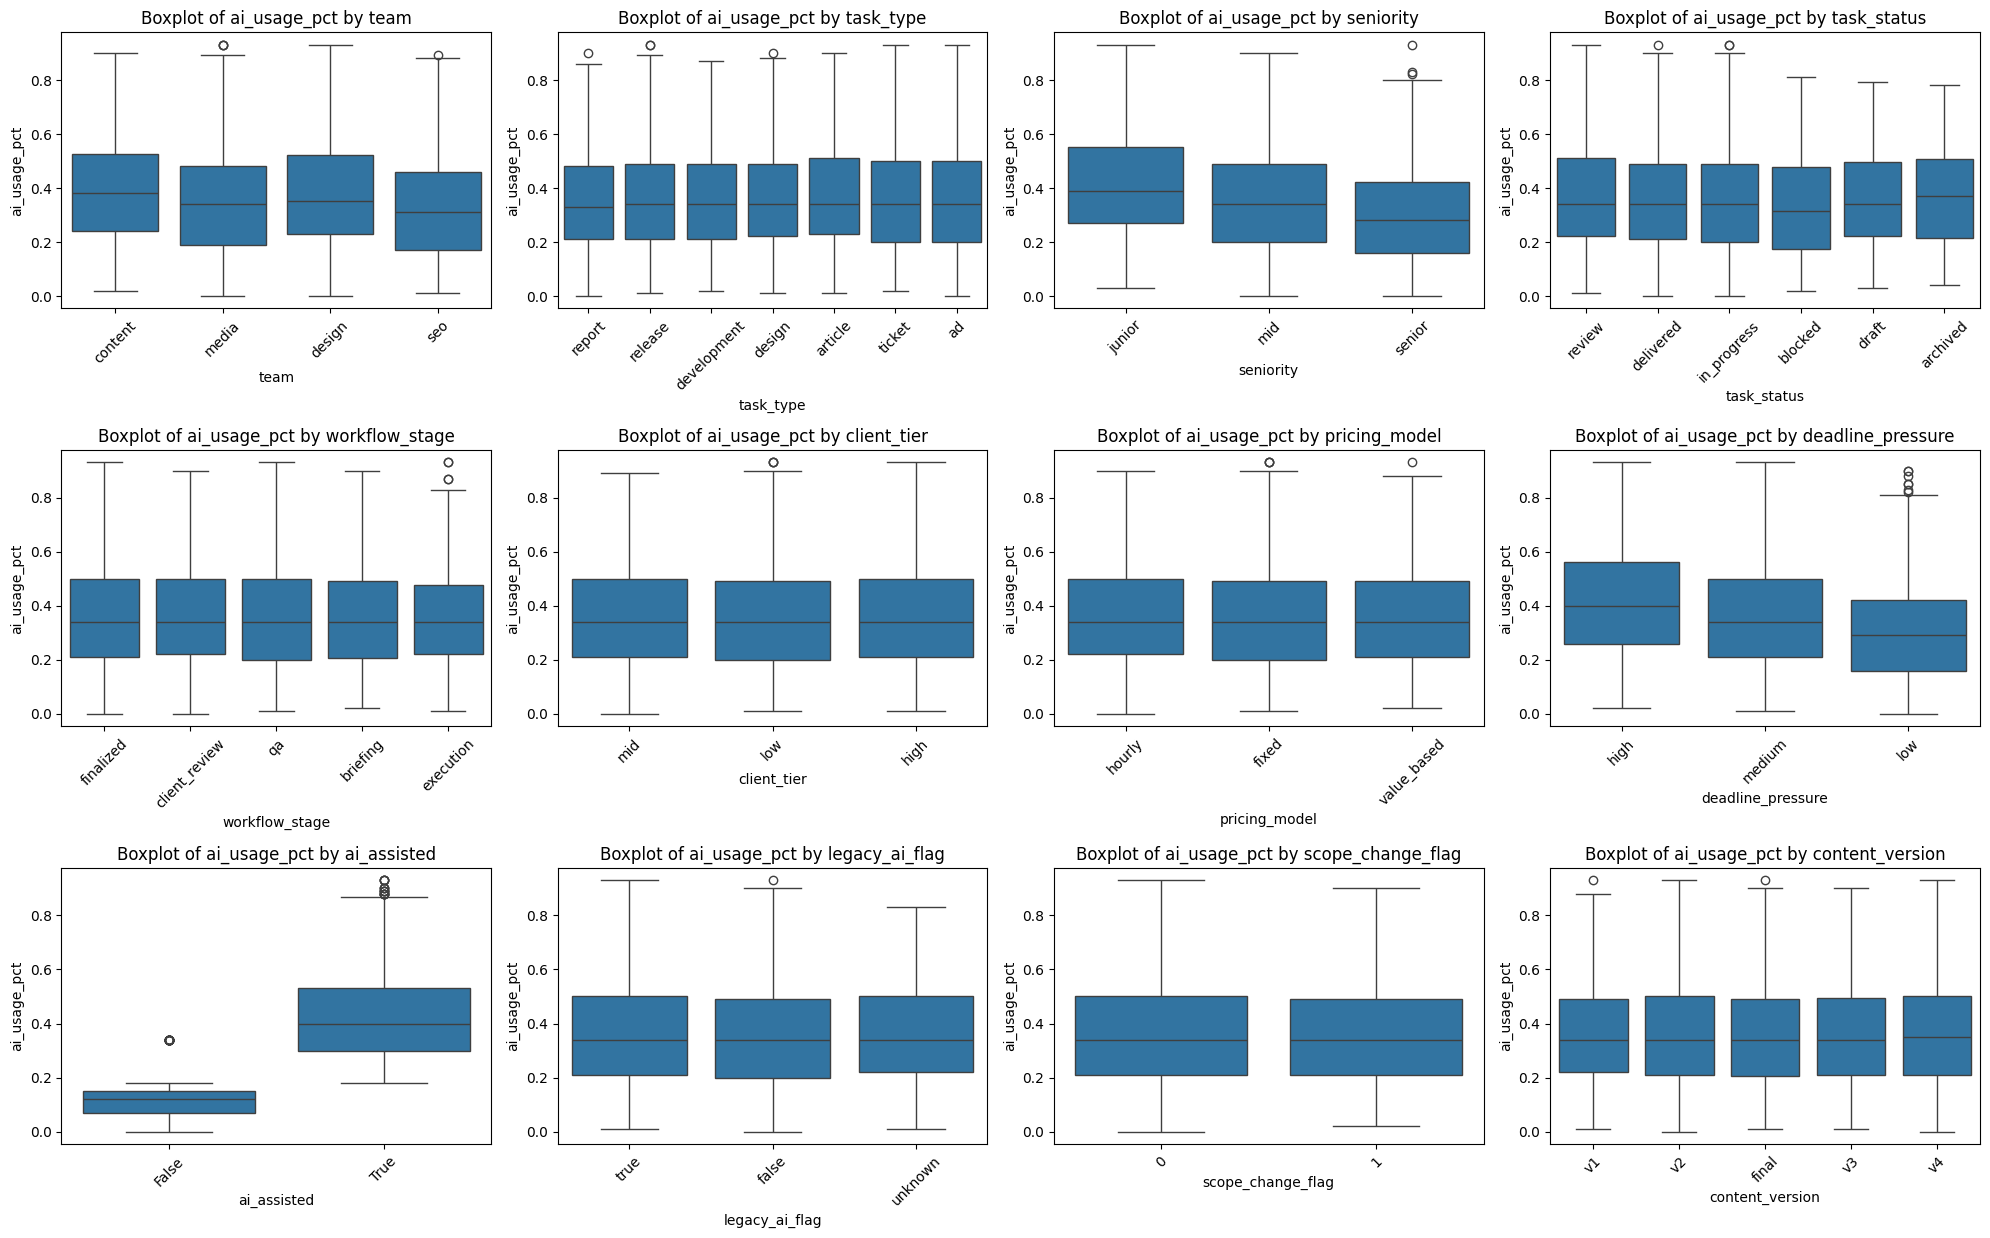

In [144]:
#boxplot for categorical variables
plt.figure(figsize=(20, 20))
for i, col in enumerate(cat_cols):
    plt.subplot(5, 4, i + 1)
    sns.boxplot(x=final_df[col], y=final_df["ai_usage_pct"])
    plt.title(f"Boxplot of ai_usage_pct by {col}")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

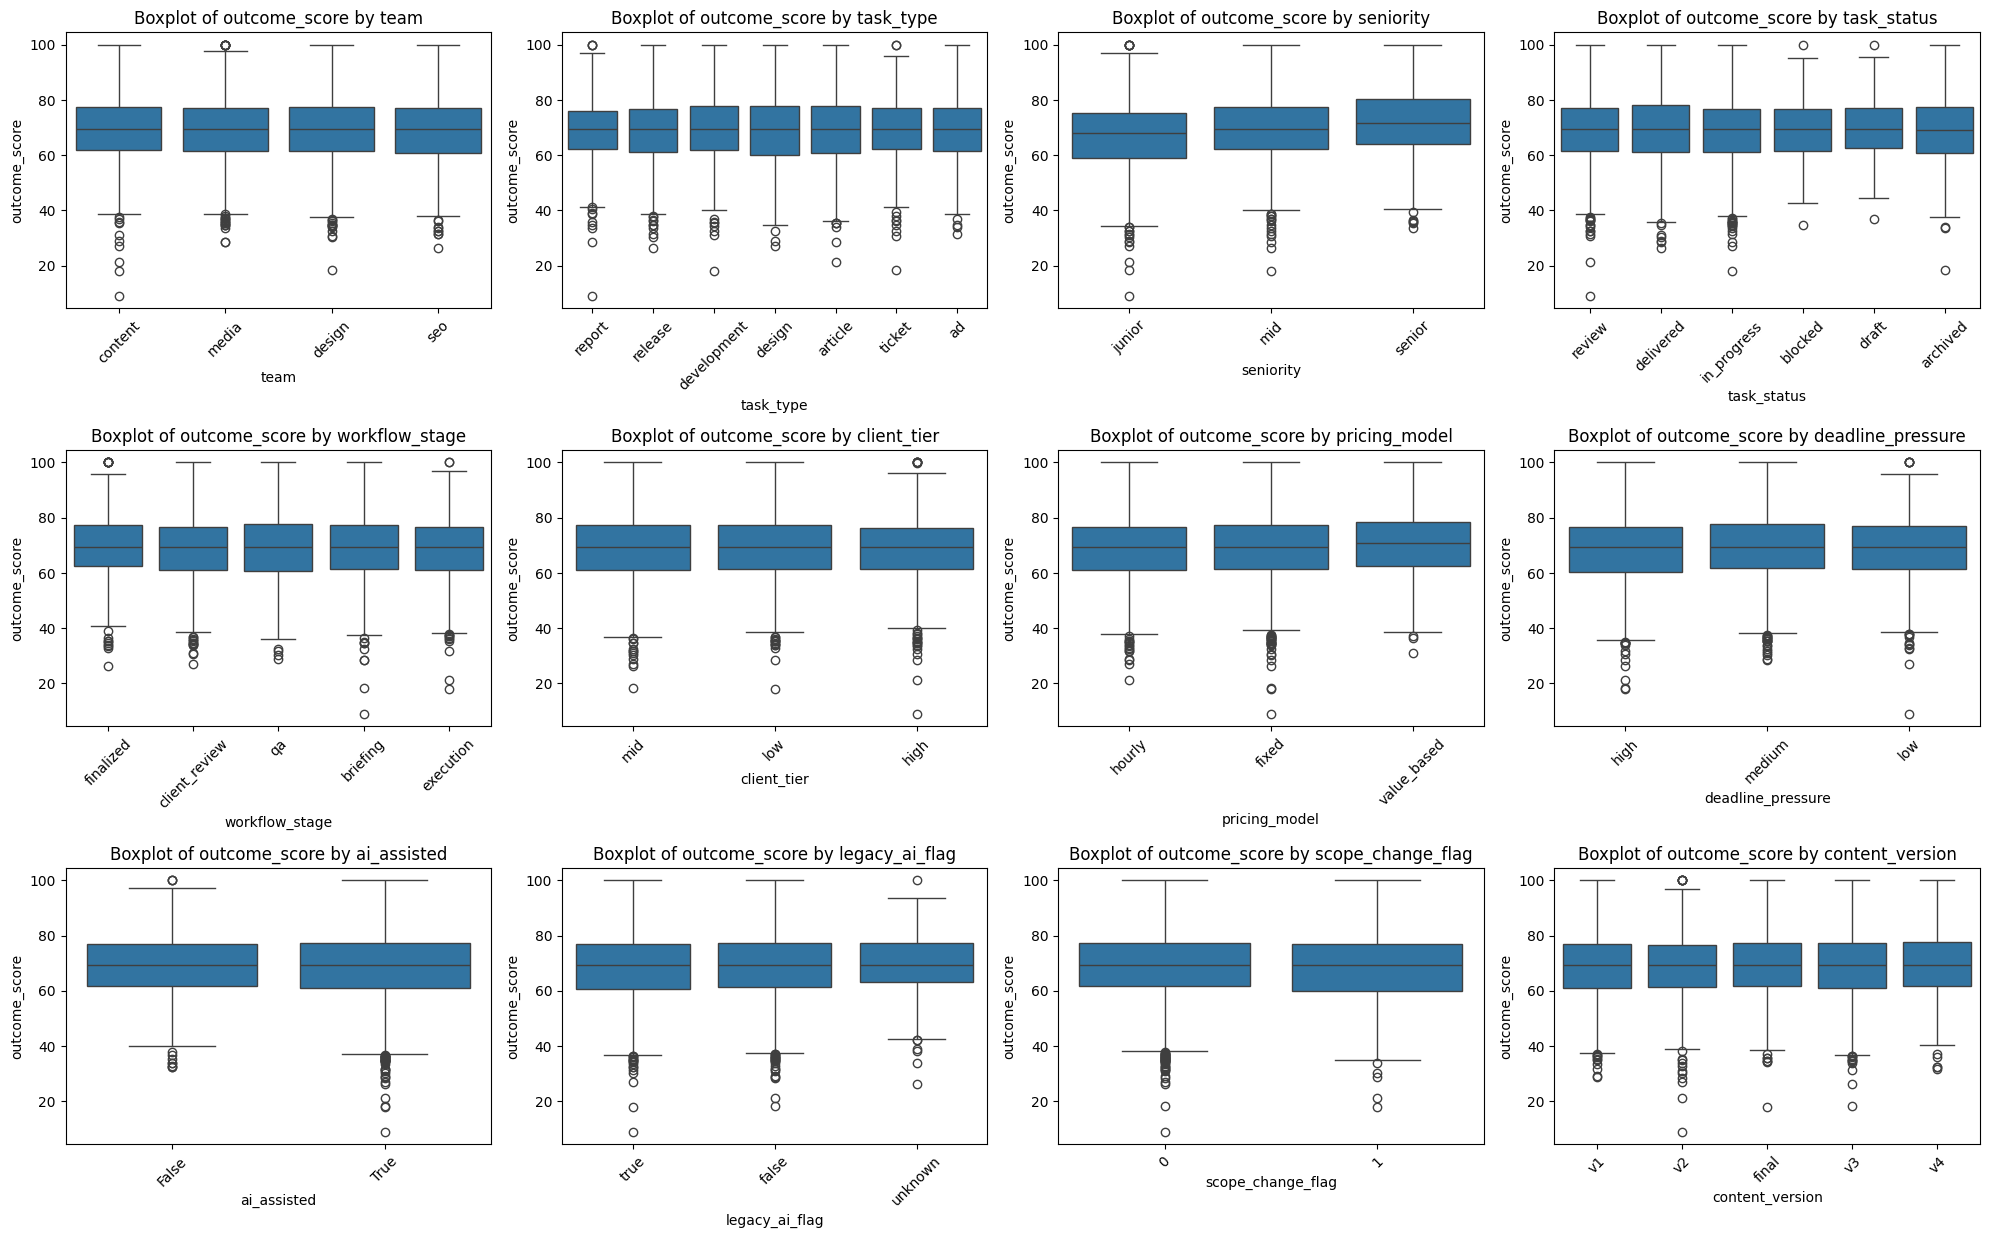

In [145]:
plt.figure(figsize=(20, 20))
for i, col in enumerate(cat_cols):
    plt.subplot(5, 4, i + 1)
    sns.boxplot(x=final_df[col], y=final_df["outcome_score"])
    plt.title(f"Boxplot of outcome_score by {col}")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

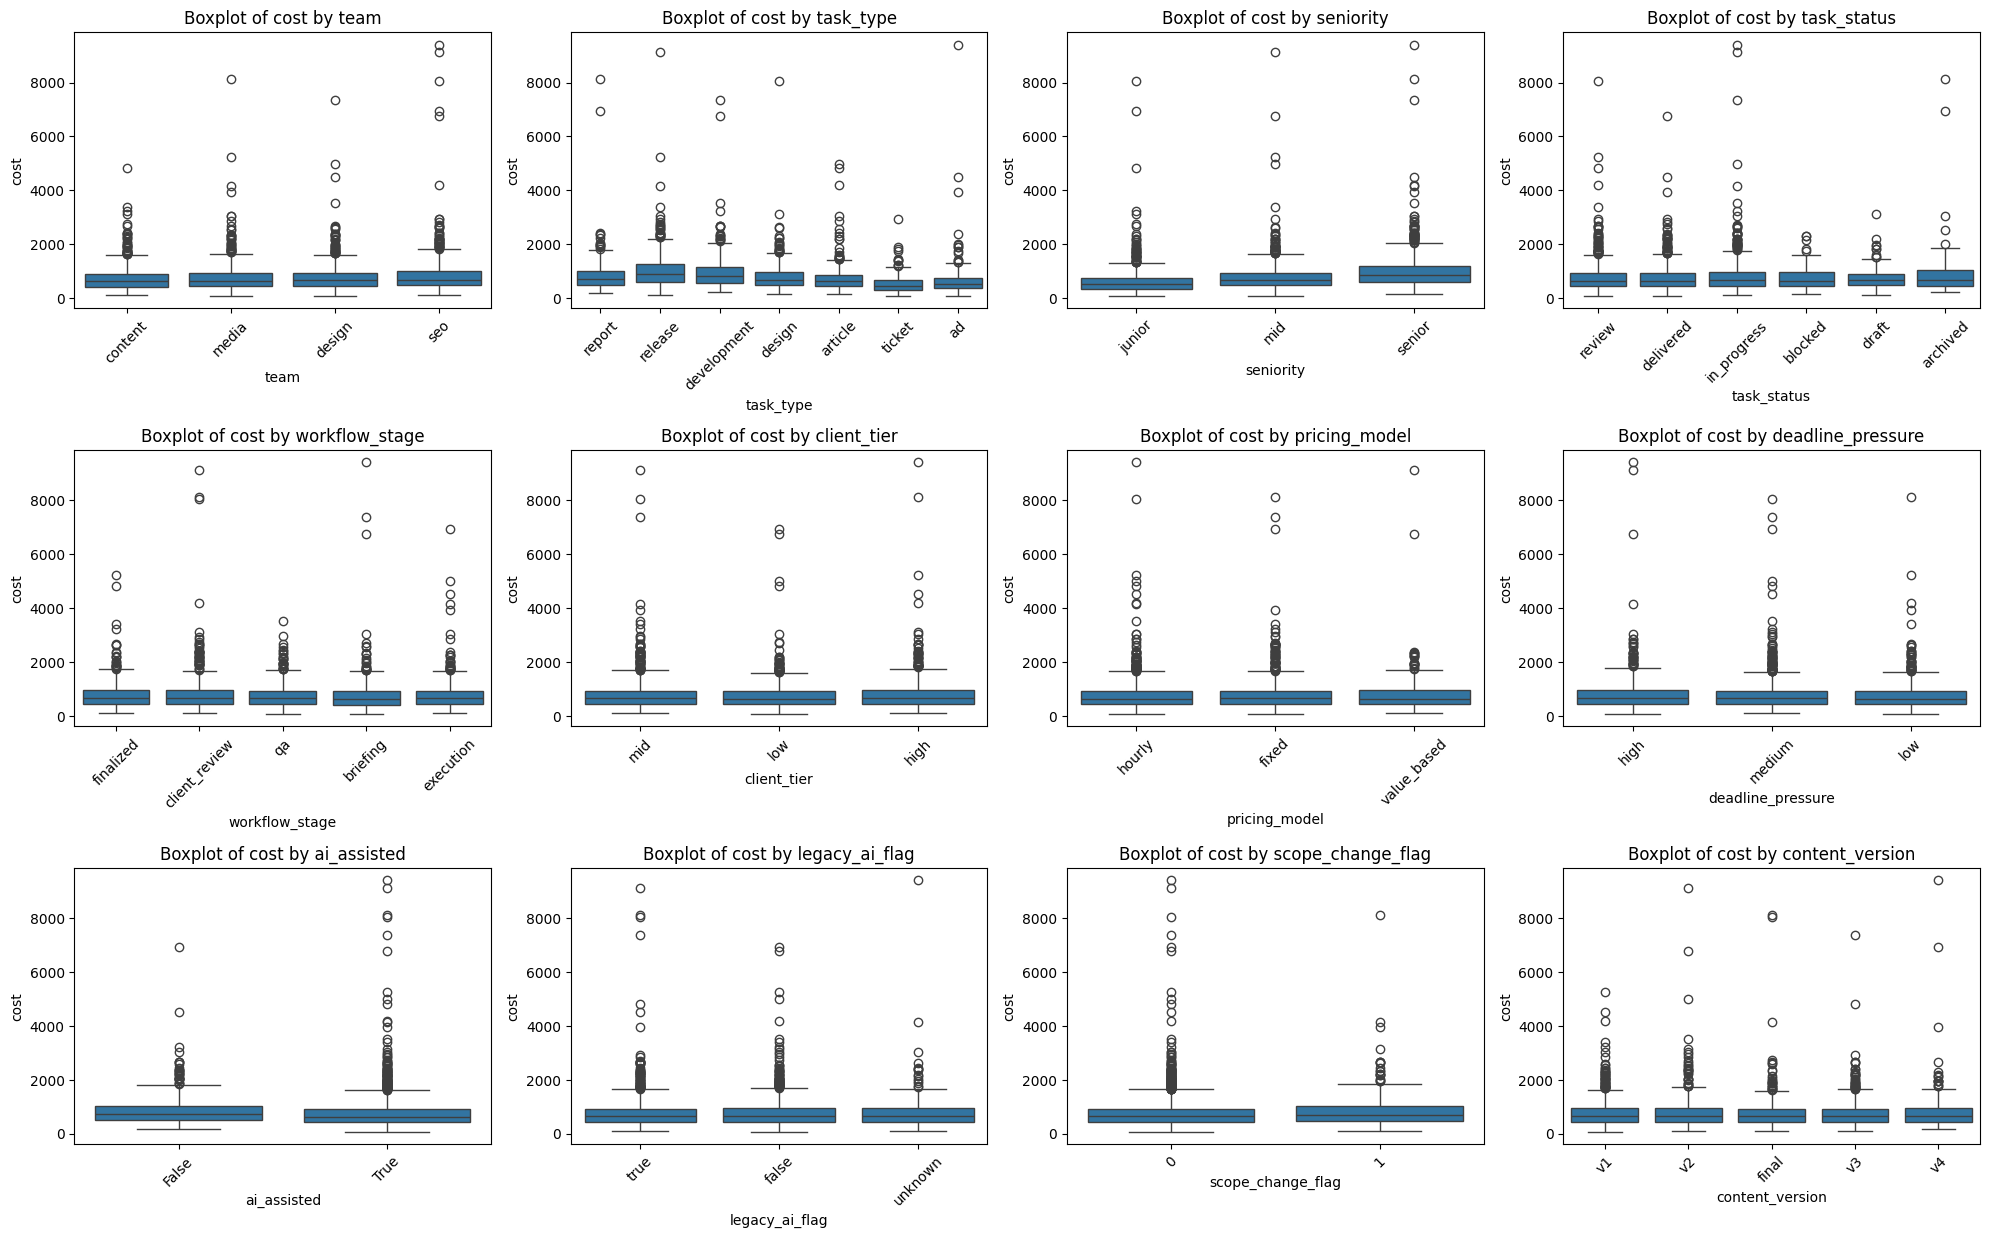

In [146]:
plt.figure(figsize=(20, 20))
for i, col in enumerate(cat_cols):
    plt.subplot(5, 4, i + 1)
    sns.boxplot(x=final_df[col], y=final_df["cost"])
    plt.title(f"Boxplot of cost by {col}")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Feature Engineering

We create derived variables that directly address the research questions around margin impact, quality, speed, and AI usage intensity.

### 7.1 Cost Metrics

In [147]:
final_df["rework_ratio"] = final_df["rework_hours"] / final_df["hours_spent"]
final_df["cost_ratio"] = final_df["cost"] / final_df["revenue"]
final_df["efficiency"] = final_df["billable_hours"] / final_df["hours_spent"]

# rework_ratio: share of total hours spent on corrections — higher values indicate more waste
# cost_ratio: how much of each euro of revenue is absorbed by costs
# efficiency: how much time spent on a task is actually billable to the client.
# if effciency:
    # = 1 all worked hours are billable
    # > 1 More hours are billed than actually spent. This is generally a positive outcome and may reflect high productivity.
    # < 1 Fewer hours are billed than worked. This indicates inefficiency, as some time is not generating revenue

### 7.2 Speed Metric — Delivery Time

We compute `delivery_time` as the number of calendar days between task creation and delivery. We also flag 14 anomalous rows where `delivered_at < created_at`, likely caused by swapped date entries. We also noticed that in 1448 cases "delivered_at < updated_at".

In [148]:
final_df["delivery_time"] = (final_df["delivered_at"] - final_df["created_at"]).dt.days
(final_df['delivered_at'] < final_df['created_at']).sum()
(final_df['delivered_at'] < final_df['updated_at']).sum()
col_to_see = ["task_id", "created_at", "delivered_at", "project_id", "team"]

final_df[final_df["delivered_at"] < final_df["created_at"]][col_to_see]

,task_id,created_at,delivered_at,project_id,team
89,T00089,2025-10-06,2025-10-05,P052,media
403,T00403,2026-02-09,2026-02-08,P035,seo
878,T00878,2026-03-29,2026-03-26,P035,seo
1083,T01083,2025-11-13,2025-11-12,P024,media
1112,T01112,2025-12-06,2025-12-05,P055,design
1163,T01163,2026-05-03,2026-04-30,P003,content
1169,T01169,2026-01-21,2026-01-20,P045,design
1230,T01230,2026-04-20,2026-04-17,P013,content
2127,T02127,2026-05-01,2026-04-30,P054,content
2131,T02131,2025-10-19,2025-10-16,P033,content


The 1448 rows where `delivered_at < updated_at` are treated as data entry swaps. We swap the two dates for those rows and recompute `delivery_time`. Thanks to this change we also fixed the problem of `delivered_at < created_at`, no additional code was needed.

In [149]:
# identify rows with swapped dates and swap them back  
neg_mask = final_df["delivered_at"] < final_df["updated_at"]  
final_df.loc[neg_mask, ["updated_at", "delivered_at"]] = final_df.loc[neg_mask, ["delivered_at", "updated_at"]].values  
final_df["delivery_time"] = (final_df["delivered_at"] - final_df["updated_at"]).dt.days  
print("Remaining negative delivery_time:", (final_df["delivery_time"] < 0).sum())

# check if everithing has worked well
print((final_df['delivered_at'] < final_df['created_at']).sum())
print((final_df['delivered_at'] < final_df['updated_at']).sum())

Remaining negative delivery_time: 0
0
0


In [150]:
# handling 38 nan values previously spotted adding the mean between delivered_at - updated_at
# we also update the delivery_time, previously computed

final_df['delivered_at'] = final_df['delivered_at'].fillna(final_df['updated_at'] + (final_df['delivered_at'] - final_df['updated_at']).mean())
final_df["delivery_time"] = (final_df["delivered_at"] - final_df["created_at"]).dt.days
#checking if there are other missingness
missing_values = final_df.isnull().sum()
print(missing_values[missing_values > 0])

jira_ticket    339
dtype: int64


### 7.3 AI Complexity Interaction and Error & Revision Rates

In [151]:
final_df["ai_complexity"] = final_df["task_complexity_score"] * final_df["ai_usage_pct"]

# Task complexity is measured on a discrete scale from 1 to 5. This new column is a proxy to see whether the effectiveness of AI varies across different levels of complexity.

In [152]:
final_df["error_rate"] = final_df["errors"] / final_df["hours_spent"]
final_df["revisions_rate"] = final_df["revisions"] / final_df["hours_spent"]

### 7.4 AI_Group

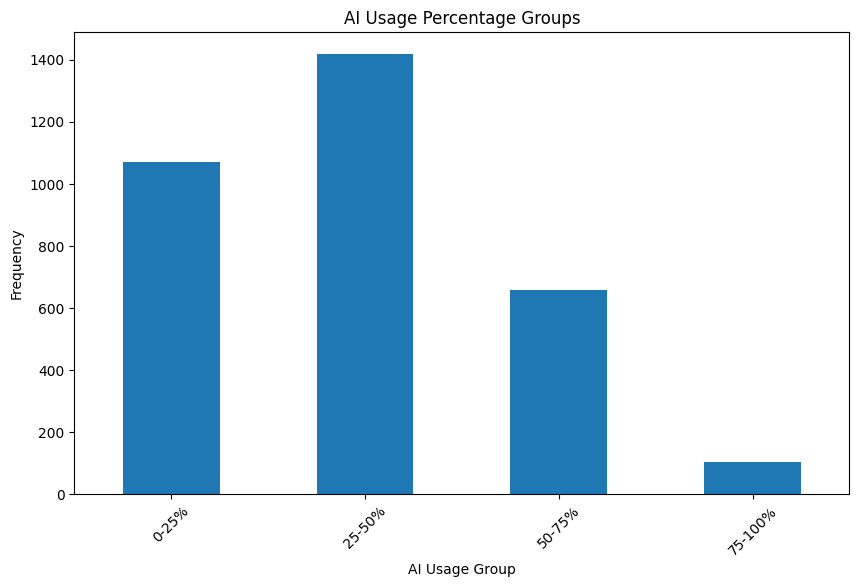

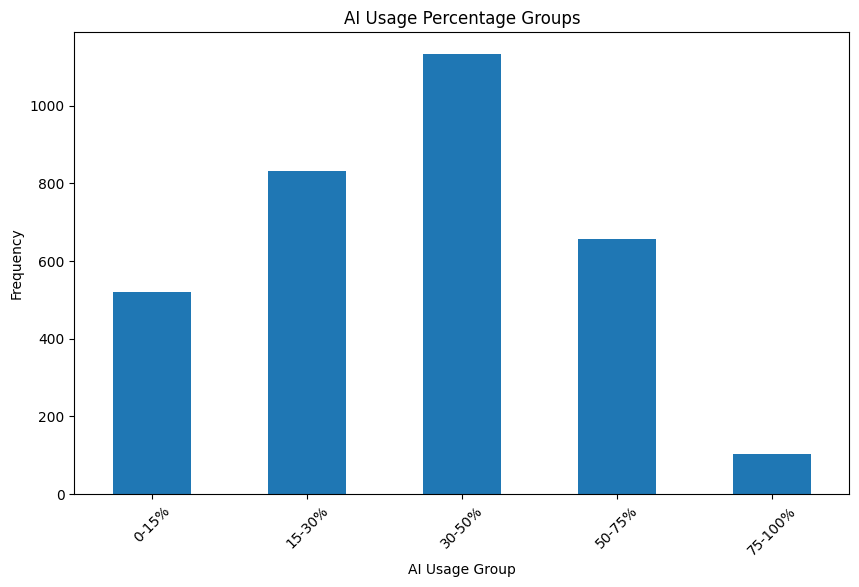

In [153]:
#bins su ai usage_pct: 0-25% / 25-50% / 50-75% / 75-100% chiamandola ai_group
final_df["ai_group"] = pd.cut(final_df["ai_usage_pct"], bins=[-1, 0.25, 0.5, 0.75, 1], labels=["0-25%", "25-50%", "50-75%", "75-100%"])
final_df["ai_group"].value_counts().sort_index()
plt.figure(figsize=(10, 6))
final_df["ai_group"].value_counts().sort_index().plot(kind="bar")
plt.title("AI Usage Percentage Groups")
plt.xlabel("AI Usage Group")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

final_df["ai_group"] = pd.cut(final_df["ai_usage_pct"], bins=[-1, 0.15, 0.3, 0.5, 0.75, 1], labels=["0-15%", "15-30%", "30-50%", "50-75%", "75-100%"])
final_df["ai_group"].value_counts().sort_index()

# visualize ai_group distribution
plt.figure(figsize=(10, 6))
final_df["ai_group"].value_counts().sort_index().plot(kind="bar")
plt.title("AI Usage Percentage Groups")
plt.xlabel("AI Usage Group")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

### 7.5 Inconsistency: `ai_assisted = False` but `ai_usage_pct > 0`



685 rows have ai_assisted = False despite a positive ai_usage_pct.
We found that 519 cases fall within the 0–15% usage bucket, suggesting low-level AI involvement that was not formally flagged as assisted.
An additional 136 cases fall within the 15–30% range, indicating that most inconsistencies are still concentrated at relatively low levels of AI usage. Only 30 cases exceed 30%, and none are observed above 50%.


**Resolution strategy:** we compute the median `ai_usage_pct` among these inconsistent rows and use it as a threshold. Tasks above the threshold are reclassified as `ai_assisted = True`; tasks at or below it are treated as genuinely non-assisted and their `ai_usage_pct` is set to 0.

In [154]:
# inspect ai_usage_pct distribution for inconsistent rows (ai_assisted=False but ai_usage_pct > 0)  
# gestire il problema ai usage / ai assisted
inconsistent_mask = (final_df["ai_assisted"] == False) & (final_df["ai_usage_pct"] > 0)  
print("Inconsistent rows:", inconsistent_mask.sum())  
print()  
print(final_df[inconsistent_mask]["ai_usage_pct"].describe())  
print()  
print("Distribution across ai_group:")  
print(final_df[inconsistent_mask]["ai_group"].value_counts())

Inconsistent rows: 685

count    685.000000
mean       0.118409
std        0.065219
min        0.010000
25%        0.070000
50%        0.120000
75%        0.150000
max        0.340000
Name: ai_usage_pct, dtype: float64

Distribution across ai_group:
ai_group
0-15%      519
15-30%     136
30-50%      30
50-75%       0
75-100%      0
Name: count, dtype: int64


In [155]:
 # we use the median of ai_usage_pct among these rows as the threshold  

threshold = final_df[inconsistent_mask]["ai_usage_pct"].median()  
print(f"Threshold: {threshold:.3f}")  

# rows above threshold: reclassify as ai_assisted = True  
above_threshold = inconsistent_mask & (final_df["ai_usage_pct"] > threshold)  
final_df.loc[above_threshold, "ai_assisted"] = True  

# rows at or below threshold: set ai_usage_pct = 0 (treat as non-assisted)  
below_threshold = inconsistent_mask & (final_df["ai_usage_pct"] <= threshold)  
final_df.loc[below_threshold, "ai_usage_pct"] = 0  

# verify: no inconsistent rows should remain  
remaining = (final_df["ai_assisted"] == False) & (final_df["ai_usage_pct"] > 0)  
print(f"Remaining inconsistencies: {remaining.sum()}")  
print()  
print("Updated ai_assisted distribution:")  
print(final_df["ai_assisted"].value_counts())  

Threshold: 0.120
Remaining inconsistencies: 0

Updated ai_assisted distribution:
ai_assisted
True     2864
False     384
Name: count, dtype: int64


### 7.6 Margin & Profitability Variables

These features directly address the reaserch question 1 (margin impact of AI) and reaserch question 5 (threshold detection).  
`profit_margin` normalises profit by revenue, making tasks of different sizes comparable.  
`is_loss` is a binary flag to isolate tasks where the firm lost money.

In [156]:
# profit margin as a share of revenue  
final_df["profit_margin"] = final_df["profit"] / final_df["revenue"]
final_df["profit_per_hour"] = final_df["profit"] / final_df["hours_spent"]
final_df["revenue_per_hour"] = final_df["revenue"] / final_df["hours_spent"]

# binary flag: did this task generate a loss?  
final_df["is_loss"] = (final_df["profit"] < 0).astype(int)  

final_df[["profit", "profit_margin", "profit_per_hour", "revenue_per_hour", "is_loss"]].describe()  

,profit,profit_margin,profit_per_hour,revenue_per_hour,is_loss
count,3248.000000,3248.000000,3248.000000,3248.000000,3248.000000
mean,349.263114,0.148953,99.889272,221.567557,0.251539
std,888.072715,0.764017,2219.490372,2956.067534,0.433965
min,-8510.549511,-16.736802,-26539.473176,3.737055,0.000000
25%,-2.610000,-0.004855,-0.266774,61.570059,0.000000
50%,254.645000,0.290493,23.375599,81.430198,0.000000
75%,590.400000,0.513023,53.291196,109.538765,1.000000
max,14006.644324,0.962587,102291.000000,127177.500000,1.000000


### 7.7 AI Threshold Analysis — Margin by AI Group

To answer RQ5 (when does AI harm the margin?), we compute mean `profit_margin` and loss rate across the three `ai_group` buckets.  
Using `ai_group` rather than arbitrary deciles is more robust after the N.2 correction, which set `ai_usage_pct = 0` 

  ai_group  mean_profit_margin  loss_rate     n
0    0-15%            0.094599   0.303263   521
1   15-30%            0.025343   0.300120   833
2   30-50%            0.196759   0.231244  1133
3   50-75%            0.236360   0.205167   658
4  75-100%            0.339304   0.116505   103


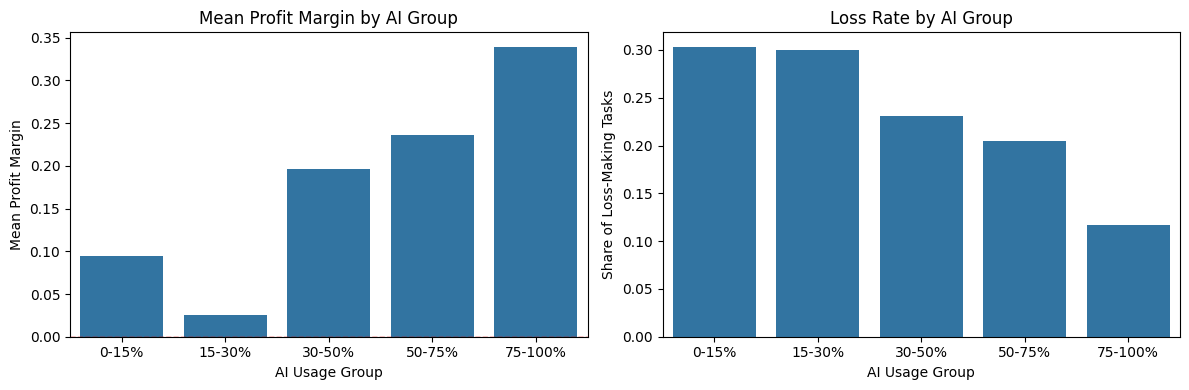

In [157]:
# mean profit margin and loss rate by ai_group  
ai_margin_df = final_df.groupby("ai_group", observed=True).agg(  
    mean_profit_margin=("profit_margin", "mean"),  
    loss_rate=("is_loss", "mean"),  
    n=("profit_margin", "count")  
).reset_index()  
print(ai_margin_df)  

fig, axes = plt.subplots(1, 2, figsize=(12, 4))  

sns.barplot(data=ai_margin_df, x="ai_group", y="mean_profit_margin", ax=axes[0])  
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)  
axes[0].set_title("Mean Profit Margin by AI Group")  
axes[0].set_xlabel("AI Usage Group")  
axes[0].set_ylabel("Mean Profit Margin")  

sns.barplot(data=ai_margin_df, x="ai_group", y="loss_rate", ax=axes[1])  
axes[1].set_title("Loss Rate by AI Group")  
axes[1].set_xlabel("AI Usage Group")  
axes[1].set_ylabel("Share of Loss-Making Tasks")  

plt.tight_layout()  
plt.show()  

### 7.8 Quality vs Speed Decomposition

To address RQ4 (AI → quality or just speed?), we build two separate indices and compare them across `ai_group`.

**Quality index** — combines `outcome_score` (0–100, higher is better) and `rework_ratio` (rework / total hours, lower is better). Both normalised to [0,1] before combining.

**Speed index** — uses `sla_ratio = delivery_time / sla_days`, which measures delivery speed relative to the agreed client deadline. A value < 1 means early, > 1 means late. More meaningful than raw `delivery_time` because it accounts for different SLA windows across tasks. The index is then inverted so that higher = faster.

          quality_index  speed_index
ai_group                            
0-15%          0.661248     0.716940
15-30%         0.656300     0.710297
30-50%         0.659162     0.724318
50-75%         0.656437     0.737425
75-100%        0.618636     0.723263


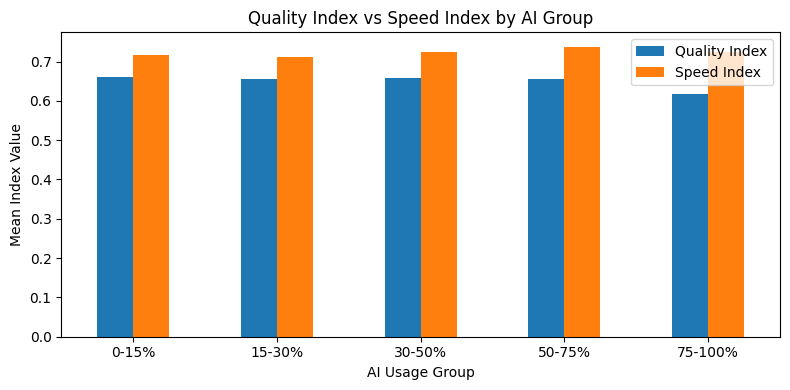

In [158]:
# sla_ratio: delivery_time relative to the agreed SLA — < 1 means delivered early, > 1 means late  
final_df["sla_ratio"] = final_df["delivery_time"] / final_df["sla_days"]  

# quality index: normalise outcome_score and rework_ratio then combine  
final_df["outcome_norm"] = (final_df["outcome_score"] - final_df["outcome_score"].min()) / (final_df["outcome_score"].max() - final_df["outcome_score"].min())  
final_df["rework_norm"] = (final_df["rework_ratio"] - final_df["rework_ratio"].min()) / (final_df["rework_ratio"].max() - final_df["rework_ratio"].min())  
final_df["quality_index"] = final_df["outcome_norm"] - final_df["rework_norm"]  # high outcome, low rework = high quality  

# speed index: normalise sla_ratio then invert so that higher = faster  
final_df["sla_ratio_norm"] = (final_df["sla_ratio"] - final_df["sla_ratio"].min()) / (final_df["sla_ratio"].max() - final_df["sla_ratio"].min())  
final_df["speed_index"] = 1 - final_df["sla_ratio_norm"]  # lower sla_ratio = faster = higher speed_index  

# compare quality and speed across ai_group  
qs_summary = final_df.groupby("ai_group", observed=True)[["quality_index", "speed_index"]].mean()  
print(qs_summary)  

qs_summary.plot(kind="bar", figsize=(8, 4), rot=0)  
plt.title("Quality Index vs Speed Index by AI Group")  
plt.ylabel("Mean Index Value")  
plt.xlabel("AI Usage Group")  
plt.legend(["Quality Index", "Speed Index"])  
plt.tight_layout()  
plt.show()  

## 8. Drop Identifier Columns & Final Overview

Columns that are pure identifiers or metadata (`task_id`, `jira_ticket`, `created_by`, `project_id`, `missing_flag`) carry no analytical or predictive value. We drop them from `final_df` before export, then print a summary of all columns in the final dataset.

In [159]:
# drop identifier and metadata columns  
cols_to_drop = ["task_id", "jira_ticket", "created_by", "project_id", "missing_flag"]  
final_df = final_df.drop(columns=cols_to_drop, errors="ignore")  

print("final_df shape:", final_df.shape)  
print()  
print("Columns in final_df:")  
print(final_df.dtypes)  

final_df shape: (3248, 48)

Columns in final_df:
client                              str
client_tier                         str
team                                str
task_type                           str
seniority                           str
task_complexity_score             int64
brief_quality_score             float64
deadline_pressure                   str
scope_change_flag                 int64
pricing_model                       str
created_at               datetime64[us]
delivered_at             datetime64[us]
sla_days                        float64
sla_breach                        int64
hours_spent                     float64
billable_hours                  float64
ai_usage_pct                    float64
ai_assisted                        bool
revisions                         int64
errors                            int64
rework_hours                    float64
outcome_score                   float64
revenue                         float64
cost                           

### 8.1 Export `final_df` — Categorical Variables as-is

`final_df` contains all cleaning, imputations, and engineered features. Categorical columns are kept in their original string format, suitable for descriptive analysis and tree-based models.

In [160]:
# convert datetime columns to string for CSV export  
final_df_export = final_df.copy()  
for col in ["created_at", "delivered_at", "updated_at"]:  
    if col in final_df_export.columns:  
        final_df_export[col] = final_df_export[col].astype(str)  

final_df_export.to_csv("final_df.csv", index=False)  
print("Saved: final_df.csv — shape:", final_df_export.shape)  
final_df_export.head()  

Saved: final_df.csv — shape: (3248, 48)


,client,client_tier,team,task_type,seniority,task_complexity_score,brief_quality_score,deadline_pressure,scope_change_flag,pricing_model,...,profit_margin,profit_per_hour,revenue_per_hour,is_loss,sla_ratio,outcome_norm,rework_norm,quality_index,sla_ratio_norm,speed_index
0,Client_F,mid,content,report,junior,2,3.0,high,0,hourly,...,0.305033,19.913499,65.283093,0,0.800000,0.669560,0.000632,0.668928,0.145455,0.854545
1,Client_H,low,media,release,junior,1,2.0,medium,0,fixed,...,0.594834,52.923319,88.971639,0,0.285714,0.810879,0.001081,0.809798,0.051948,0.948052
2,Client_D,low,design,development,junior,3,4.0,medium,0,fixed,...,0.734351,119.414201,162.611834,0,1.400000,0.740659,0.000737,0.739922,0.254545,0.745455
3,Client_E,mid,content,design,mid,3,2.0,low,0,hourly,...,0.363321,30.489594,83.919224,0,2.000000,0.663736,0.000000,0.663736,0.363636,0.636364
4,Client_C,low,design,article,senior,2,5.0,low,0,fixed,...,0.527755,63.183811,119.721754,0,1.000000,0.663736,0.000326,0.663411,0.181818,0.818182


### 8.2 Export `final_encoded` — One-Hot Encoded Categorical Variables

`final_encoded` is derived directly from `final_df`. Datetime columns are dropped (already represented by `delivery_time` and `sla_ratio`), boolean columns are cast to int, and all remaining string/category columns are one-hot encoded with `drop_first=True` to avoid multicollinearity.

In [161]:
# build final_encoded from final_df  
final_encoded = final_df.copy()  

# drop datetime columns — already represented by delivery_time and sla_ratio  
date_cols = ["created_at", "delivered_at", "updated_at"]  
final_encoded = final_encoded.drop(columns=[c for c in date_cols if c in final_encoded.columns])  

# convert bool columns to int  
bool_cols = final_encoded.select_dtypes(include="bool").columns.tolist()  
final_encoded[bool_cols] = final_encoded[bool_cols].astype(int)  

# one-hot encode all remaining string/object/category columns  
cat_to_encode = final_encoded.select_dtypes(include=["object", "category"]).columns.tolist()  
print("Columns to encode:", cat_to_encode)  
final_encoded = pd.get_dummies(final_encoded, columns=cat_to_encode, drop_first=True)  

final_encoded.to_csv("final_encoded.csv", index=False)  
print("Saved: final_encoded.csv — shape:", final_encoded.shape)  
final_encoded.head()  

Columns to encode: ['client', 'client_tier', 'team', 'task_type', 'seniority', 'deadline_pressure', 'pricing_model', 'task_status', 'workflow_stage', 'legacy_ai_flag', 'content_version', 'ai_group']
Saved: final_encoded.csv — shape: (3248, 96)


/var/folders/64/3w707y752n76rvfcs7n14qk80000gn/T/ipykernel_92444/1063849521.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_to_encode = final_encoded.select_dtypes(include=["object", "category"]).columns.tolist()


,task_complexity_score,brief_quality_score,scope_change_flag,sla_days,sla_breach,hours_spent,billable_hours,ai_usage_pct,ai_assisted,revisions,...,legacy_ai_flag_true,legacy_ai_flag_unknown,content_version_v1,content_version_v2,content_version_v3,content_version_v4,ai_group_15-30%,ai_group_30-50%,ai_group_50-75%,ai_group_75-100%
0,2,3.0,0,10.0,0,7.63,5.14,0.75,1,1,...,True,False,True,False,False,False,False,False,True,False
1,1,2.0,0,7.0,0,9.52,8.22,0.00,0,1,...,False,False,True,False,False,False,False,False,False,False
2,3,4.0,0,5.0,1,8.45,6.15,0.37,1,2,...,True,False,False,True,False,False,False,True,False,False
3,3,2.0,0,3.0,0,28.35,24.22,0.00,0,4,...,False,False,True,False,False,False,False,False,False,False
4,2,5.0,0,7.0,0,5.93,4.44,0.20,1,2,...,True,False,False,True,False,False,True,False,False,False


In [162]:
#